# 숙제 3

데이터과학 입문

원중호 (서울대학교 통계학과)  
June 2026

## 지시사항

제출마감 2026-06-15 23:00

1.  R과 Python을 모두 사용하여 사용된 코드와 데이터랭글링 절차,
    분석결과를 설명한다. 두 언어의 분석결과가 차이가 있으면 그 이유를
    설명한다.
2.  [Quarto
    Markdown](https://quarto.org/docs/authoring/markdown-basics.html)을
    사용한다. 제공된 숙제 `.qmd` 파일에 본인의 답안을 “답안” 절에
    추가하여 제출한다. Quarto Markdown은 RStudio 또는 Visual Studio
    Code에 [Quarto
    Extension](https://marketplace.visualstudio.com/items?itemName=quarto.quarto)을
    추가하여 컴파일, 다른 문서 형식으로 변환할 수 있다.
3.  R의 `reticulate` 패키지를 사용하면 하나의 `.qmd` 파일 안에서 R과
    Python을 동시에 사용할 수 있다. 이때 다음 문법을 사용하여 두 언어
    코드를 탭으로 구분한다. 숙제 `.qmd` 파일은 `reticulate`을 사용하도록
    준비되어 있다.

```` markdown
::: {.panel-tabset}

## R

```{r}
R code
```

## Python

```{python}
Python code
```

:::
````

1.  `.qmd`를 컴파일하여 생성된 `.html` 파일을 함께 저장소에 제출한다.
2.  함께 제공된 `student.yml`을 함께 작성하여 저장소에 제출한다.

## 평가 기준

1.  재현성: 제출된 저장소의 `.qmd` 파일을 컴파일하여 함께 제출된 `.html`
    파일과 동일한 결과가 나와야 한다.
2.  분석의 정확성: 분석은 올바른 기술적 세부 사항을 포함하여 수행되어야
    한다.
3.  보고서의 전반적인 품질: 데이터 가공 및 분석 결과가 명확하고 자세하게
    설명되어야 한다.
4.  코드의 전반적인 품질: 코드는 체계적으로 정리되어 있어야 하며,
    가독성을 높이기 위해 적절한 주석이 포함되어야 한다.

#### **늦게 제출된 과제물은 받지 않는다.**

## Necessary packages

## R

``` r
library(tidyverse)
library(NHANES)
library(mosaic)
library(dplyr)
library(Lahman)
library(ggplot2)
library(MASS)
library(dplyr)
library(tidyr)

select <- dplyr::select
filter <- dplyr::filter
mutate <- dplyr::mutate
rename <- dplyr::rename
```

## Python

``` python
import pandas as pd
import statsmodels.formula.api as smf
import polars as pl
import numpy as np
import pylahman
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import chi2
```

# 1부 교과서 연습문제

## 문제 1-1

1.  MDSR 10장 연습문제 10.6.6

### 답안

## R

``` r
smoking <- NHANES %>%
    filter(Age >= 20) %>%
    mutate(
        SmokeNow = ifelse(Smoke100 == "No", "No", as.character(SmokeNow)),
        SmokeNow = factor(SmokeNow, levels = c("No", "Yes"))
    ) %>%
    dplyr::select(
        SmokeNow, Age, Gender, Race1, Education, MaritalStatus, HHIncome,
        BMI, PhysActive, AlcoholDay, Diabetes, HealthGen
    ) %>%
    drop_na()

# Check recoding
tally(~ SmokeNow, data = smoking)
```

    SmokeNow
      No  Yes 
    3498  966 

``` r
# Logistic regression
smoke_mod <- glm(
    SmokeNow ~ .,
    data = smoking,
    family = binomial
)

summary(smoke_mod)
```


    Call:
    glm(formula = SmokeNow ~ ., family = binomial, data = smoking)

    Coefficients:
                               Estimate Std. Error z value Pr(>|z|)    
    (Intercept)                2.035797   0.512523   3.972 7.12e-05 ***
    Age                       -0.012749   0.003411  -3.737 0.000186 ***
    Gendermale                 0.091986   0.089080   1.033 0.301778    
    Race1Hispanic             -0.810391   0.220663  -3.673 0.000240 ***
    Race1Mexican              -1.484244   0.212742  -6.977 3.02e-12 ***
    Race1White                -0.213645   0.133603  -1.599 0.109798    
    Race1Other                 0.169211   0.202995   0.834 0.404522    
    Education9 - 11th Grade   -0.015238   0.231460  -0.066 0.947510    
    EducationHigh School      -0.441531   0.226346  -1.951 0.051094 .  
    EducationSome College     -0.646783   0.225113  -2.873 0.004064 ** 
    EducationCollege Grad     -1.556857   0.244040  -6.380 1.78e-10 ***
    MaritalStatusLivePartner   0.424277   0.175286   2.420 0.015500 *  
    MaritalStatusMarried      -0.729847   0.136419  -5.350 8.79e-08 ***
    MaritalStatusNeverMarried -0.580228   0.157607  -3.681 0.000232 ***
    MaritalStatusSeparated    -0.251900   0.280440  -0.898 0.369063    
    MaritalStatusWidowed      -0.692894   0.256748  -2.699 0.006960 ** 
    HHIncome 5000-9999        -0.412761   0.394484  -1.046 0.295409    
    HHIncome10000-14999       -0.567501   0.330790  -1.716 0.086237 .  
    HHIncome15000-19999       -0.620225   0.338674  -1.831 0.067051 .  
    HHIncome20000-24999       -0.264729   0.333986  -0.793 0.427991    
    HHIncome25000-34999       -0.847972   0.319066  -2.658 0.007868 ** 
    HHIncome35000-44999       -1.262752   0.326386  -3.869 0.000109 ***
    HHIncome45000-54999       -0.826644   0.323534  -2.555 0.010617 *  
    HHIncome55000-64999       -0.338298   0.326640  -1.036 0.300347    
    HHIncome65000-74999       -1.181314   0.343565  -3.438 0.000585 ***
    HHIncome75000-99999       -0.973948   0.322269  -3.022 0.002510 ** 
    HHIncomemore 99999        -0.849950   0.311254  -2.731 0.006319 ** 
    BMI                       -0.055175   0.007188  -7.676 1.64e-14 ***
    PhysActiveYes             -0.525959   0.090295  -5.825 5.72e-09 ***
    AlcoholDay                 0.155901   0.016951   9.197  < 2e-16 ***
    DiabetesYes               -0.684025   0.177173  -3.861 0.000113 ***
    HealthGenVgood             0.556849   0.179408   3.104 0.001910 ** 
    HealthGenGood              0.991112   0.176377   5.619 1.92e-08 ***
    HealthGenFair              1.476368   0.200580   7.361 1.83e-13 ***
    HealthGenPoor              1.059182   0.343703   3.082 0.002058 ** 
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 4663.2  on 4463  degrees of freedom
    Residual deviance: 3690.5  on 4429  degrees of freedom
    AIC: 3760.5

    Number of Fisher Scoring iterations: 5

``` r
write.csv(
    NHANES,
    "NHANES.csv",
    row.names = FALSE
)
```

## Python

``` python
NHANES = pd.read_csv("NHANES.csv")

smoking = (
    NHANES.loc[NHANES["Age"] >= 20]
    .assign(
        SmokeNow=lambda df: df["SmokeNow"].where(
            df["Smoke100"] != "No", "No"
        )
    )
    [["SmokeNow", "Age", "Gender", "Race1", "Education",
      "MaritalStatus", "HHIncome", "BMI", "PhysActive",
      "AlcoholDay", "Diabetes", "HealthGen"]]
    .dropna()
)

# Check recoding
print(smoking["SmokeNow"].value_counts())
```

    SmokeNow
    No     3498
    Yes     966
    Name: count, dtype: int64

``` python
# Logistic regression
smoking["SmokeNow"] = smoking["SmokeNow"].map({"No": 0, "Yes": 1})

smoke_mod = smf.logit(
    "SmokeNow ~ Age + Gender + Race1 + Education + "
    "MaritalStatus + HHIncome + BMI + PhysActive + "
    "AlcoholDay + Diabetes + HealthGen",
    data=smoking
).fit()
```

    Optimization terminated successfully.
             Current function value: 0.413364
             Iterations 7

``` python
print(smoke_mod.summary())
```

                               Logit Regression Results                           
    ==============================================================================
    Dep. Variable:               SmokeNow   No. Observations:                 4464
    Model:                          Logit   Df Residuals:                     4429
    Method:                           MLE   Df Model:                           34
    Date:                Fri, 12 Jun 2026   Pseudo R-squ.:                  0.2086
    Time:                        05:23:34   Log-Likelihood:                -1845.3
    converged:                       True   LL-Null:                       -2331.6
    Covariance Type:            nonrobust   LLR p-value:                2.961e-182
    =================================================================================================
                                        coef    std err          z      P>|z|      [0.025      0.975]
    -------------------------------------------------------------------------------------------------
    Intercept                         2.0358      0.513      3.972      0.000       1.031       3.040
    Gender[T.male]                    0.0920      0.089      1.033      0.302      -0.083       0.267
    Race1[T.Hispanic]                -0.8104      0.221     -3.673      0.000      -1.243      -0.378
    Race1[T.Mexican]                 -1.4842      0.213     -6.977      0.000      -1.901      -1.067
    Race1[T.Other]                    0.1692      0.203      0.834      0.405      -0.229       0.567
    Race1[T.White]                   -0.2136      0.134     -1.599      0.110      -0.476       0.048
    Education[T.9 - 11th Grade]      -0.0152      0.231     -0.066      0.948      -0.469       0.438
    Education[T.College Grad]        -1.5569      0.244     -6.380      0.000      -2.035      -1.079
    Education[T.High School]         -0.4415      0.226     -1.951      0.051      -0.885       0.002
    Education[T.Some College]        -0.6468      0.225     -2.873      0.004      -1.088      -0.206
    MaritalStatus[T.LivePartner]      0.4243      0.175      2.420      0.016       0.081       0.768
    MaritalStatus[T.Married]         -0.7298      0.136     -5.350      0.000      -0.997      -0.462
    MaritalStatus[T.NeverMarried]    -0.5802      0.158     -3.681      0.000      -0.889      -0.271
    MaritalStatus[T.Separated]       -0.2519      0.280     -0.898      0.369      -0.802       0.298
    MaritalStatus[T.Widowed]         -0.6929      0.257     -2.699      0.007      -1.196      -0.190
    HHIncome[T. 5000-9999]           -0.4128      0.394     -1.046      0.295      -1.186       0.360
    HHIncome[T.10000-14999]          -0.5675      0.331     -1.716      0.086      -1.216       0.081
    HHIncome[T.15000-19999]          -0.6202      0.339     -1.831      0.067      -1.284       0.044
    HHIncome[T.20000-24999]          -0.2647      0.334     -0.793      0.428      -0.919       0.390
    HHIncome[T.25000-34999]          -0.8480      0.319     -2.658      0.008      -1.473      -0.223
    HHIncome[T.35000-44999]          -1.2628      0.326     -3.869      0.000      -1.902      -0.623
    HHIncome[T.45000-54999]          -0.8266      0.324     -2.555      0.011      -1.461      -0.193
    HHIncome[T.55000-64999]          -0.3383      0.327     -1.036      0.300      -0.979       0.302
    HHIncome[T.65000-74999]          -1.1813      0.344     -3.438      0.001      -1.855      -0.508
    HHIncome[T.75000-99999]          -0.9739      0.322     -3.022      0.003      -1.606      -0.342
    HHIncome[T.more 99999]           -0.8499      0.311     -2.731      0.006      -1.460      -0.240
    PhysActive[T.Yes]                -0.5260      0.090     -5.825      0.000      -0.703      -0.349
    Diabetes[T.Yes]                  -0.6840      0.177     -3.861      0.000      -1.031      -0.337
    HealthGen[T.Fair]                 1.4764      0.201      7.360      0.000       1.083       1.870
    HealthGen[T.Good]                 0.9911      0.176      5.619      0.000       0.645       1.337
    HealthGen[T.Poor]                 1.0592      0.344      3.082      0.002       0.386       1.733
    HealthGen[T.Vgood]                0.5568      0.179      3.104      0.002       0.205       0.908
    Age                              -0.0127      0.003     -3.737      0.000      -0.019      -0.006
    BMI                              -0.0552      0.007     -7.676      0.000      -0.069      -0.041
    AlcoholDay                        0.1559      0.017      9.197      0.000       0.123       0.189
    =================================================================================================

# 2부 데이터 분석 실무

### 분석 관련 공통 지침

1.  관측단위(observational unit)는 `playerID`와 `yearID`의 고유한
    조합으로 한다. 즉, 데이터프레임의 각 행은 한 선수의 특정 연도에
    해당해야 하고(예: 2019년 류현진), 한 선수의 특정 연도가 두 번 이상
    나타나서는 안 된다. 이적을 한 경우 원자료에서는 두 번 이상 나타날 수
    있으므로 주의해야 한다.
2.  데이터 분석을 하는 중에 필요한 경우 pivoting으로 각 행이 한명의
    선수에 해당하는 wide format data를 만들어서 연도간 비교를 하는 것은
    허용한다.

## 문제 2-1

Lahman Package의 `Teams` 데이터프레임에서 코로나 시즌인 2020년을 제외한
2010년부터 2025년 사이의 데이터를 이용하여 다음 질문에 답하라.

1.  MDSR Chapter 7 Iteration 에서 배운 Bill James의 공식을 변형한 다음
    모형을 데이터에 적합하고, 모수 $k$의 점추정치와 신뢰구간을 구하라.
    $$  WPct = \frac{RS^k}{S^k+RA^k} = \frac{1}{1+(RA/RS)^k}$$

2.  회귀계수 $\beta_1$이 위 모형의 $k$와 거의 같은 의미를 가지는
    로지스틱 회귀 모형을 세우고 이를 데이터에 적합하라. 모수와
    점추정치와 신뢰구간을 구하고 이를 1항의 결과와 비교하라.

    *주의*: 절편이 없는 모형을 적합해야 함. *힌트 1*. 로짓은
    $\log〖WPct/(1-WPct)$로 계산됨. *힌트 2*. 로짓의 역함수인 sigmoid는
    $\frac{1}{1+e^{-x}}$로 계산됨.

3.  2항의 모형 적합 결과에 대한 다음 세가지 진단 중 최소 두가지 이상을
    수행하여 모형적합이 잘 되었는지 확인하라.

    1.  Residual Deviance에 대한 해석 (카이제곱 분포와 비교)
    2.  Deviance residuals vs linear predictors ($\eta$) 산점도
    3.  관측된 WPct와 모형에서 예측하는 WPct를 산점도 그래프로 비교

4.  `WPct`를 반응변수로, `log(RA)`와 `log(RS)`를 설명변수로 하는 절편이
    없는 로지스틱선형회귀 모형을 적합하고 회귀계수들의 추정 결과를 a와
    b항의 결과와 비교하라. (유사한 모형을 얻는지 여부 등)

### 답안

#### 2-1.1

## R

``` r
# Prepare team-level data
TeamRuns <- Teams %>%
  filter(
    yearID >= 2010,
    yearID <= 2025,
    yearID != 2020
  ) %>%
  rename(RS = R) %>%
  mutate(
    WPct = W / (W + L),
    run_ratio = RS / RA
  ) %>%
  dplyr::select(yearID, teamID, lgID, WPct, run_ratio, RS, RA) %>%
  filter(
    !is.na(WPct),
    !is.na(run_ratio),
    RS > 0,
    RA > 0
  )

# Fit the modified Bill James model
fit <- nls(
  WPct ~ 1 / (1 + (1 / run_ratio)^k),
  data = TeamRuns,
  start = list(k = 2)
)

summary(fit)
```


    Formula: WPct ~ 1/(1 + (1/run_ratio)^k)

    Parameters:
      Estimate Std. Error t value Pr(>|t|)    
    k  1.75279    0.02935   59.73   <2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    Residual standard error: 0.02458 on 449 degrees of freedom

    Number of iterations to convergence: 2 
    Achieved convergence tolerance: 9.559e-07

``` r
# Point estimate and 95% confidence interval
k_hat <- coef(fit)["k"]
k_ci <- confint(fit)

cat("Estimated k =", round(k_hat, 4), "\n")
```

    Estimated k = 1.7528 

``` r
cat(
  "95% CI = (",
  round(k_ci[1], 4), ", ",
  round(k_ci[2], 4), ")\n",
  sep = ""
)
```

    95% CI = (1.6952, 1.8106)

``` r
# Fitted Bill James curve
bj_model <- function(x, k) {
  1 / (1 + (1 / x)^k)
}

# Plot observed data and fitted curve
ggplot(data = TeamRuns, aes(x = run_ratio, y = WPct)) +
  geom_vline(
    xintercept = 1,
    color = "darkgray",
    linetype = 2
  ) +
  geom_hline(
    yintercept = 0.5,
    color = "darkgray",
    linetype = 2
  ) +
  geom_point(alpha = 0.2) +
  stat_function(
    fun = function(x) bj_model(x, k_hat),
    linewidth = 2,
    color = "blue"
  ) +
  xlab("Ratio of Runs Scored to Runs Allowed") +
  ylab("Winning Percentage")
```

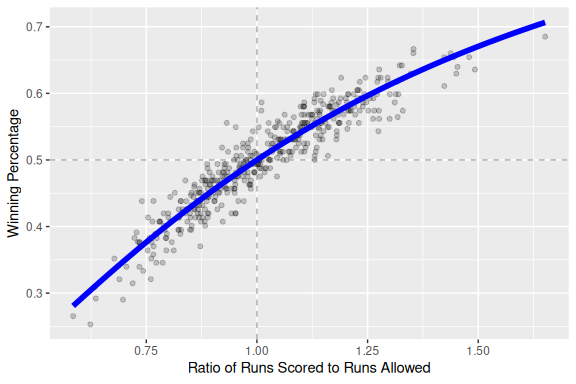

## Python

``` python
# Load Teams data
Teams = pl.from_pandas(pylahman.Teams())

# Data preprocessing
TeamRuns = (
    Teams
    .filter(
        (pl.col("yearID") >= 2010) &
        (pl.col("yearID") <= 2025) &
        (pl.col("yearID") != 2020)
    )
    .rename({"R": "RS"})
    .with_columns([
        (pl.col("W") / (pl.col("W") + pl.col("L"))).alias("WPct"),
        (pl.col("RS") / pl.col("RA")).alias("run_ratio")
    ])
    .select([
        "yearID", "teamID", "lgID",
        "WPct", "run_ratio", "RS", "RA"
    ])
    .filter(
        pl.col("WPct").is_not_null() &
        pl.col("run_ratio").is_not_null() &
        (pl.col("RS") > 0) &
        (pl.col("RA") > 0)
    )
)

# Nonlinear model
def bj_model(x, k):
    return 1 / (1 + (1 / x) ** k)

x = TeamRuns["run_ratio"].to_numpy()
y = TeamRuns["WPct"].to_numpy()

fit_result = curve_fit(
    bj_model,
    x,
    y,
    p0=[2]
)

k_hat = fit_result[0][0]
cov = fit_result[1]
se_k = np.sqrt(cov[0, 0])

ci_lower = k_hat - 1.96 * se_k
ci_upper = k_hat + 1.96 * se_k

print(f"k_hat = {k_hat:.4f}")
```

    k_hat = 1.7610

``` python
print(f"95% CI = ({ci_lower:.4f}, {ci_upper:.4f})")
```

    95% CI = (1.7021, 1.8200)

``` python
# Plot
x_grid = np.linspace(x.min(), x.max(), 500)

plt.figure(figsize=(8, 6))

plt.axvline(x=1, color="darkgray", linestyle="--")
plt.axhline(y=0.5, color="darkgray", linestyle="--")

plt.scatter(
    x,
    y,
    alpha=0.2
)

plt.plot(
    x_grid,
    bj_model(x_grid, k_hat),
    linewidth=2,
    color="blue"
)

plt.xlabel("Ratio of Runs Scored to Runs Allowed")
plt.ylabel("Winning Percentage")
plt.show()
```

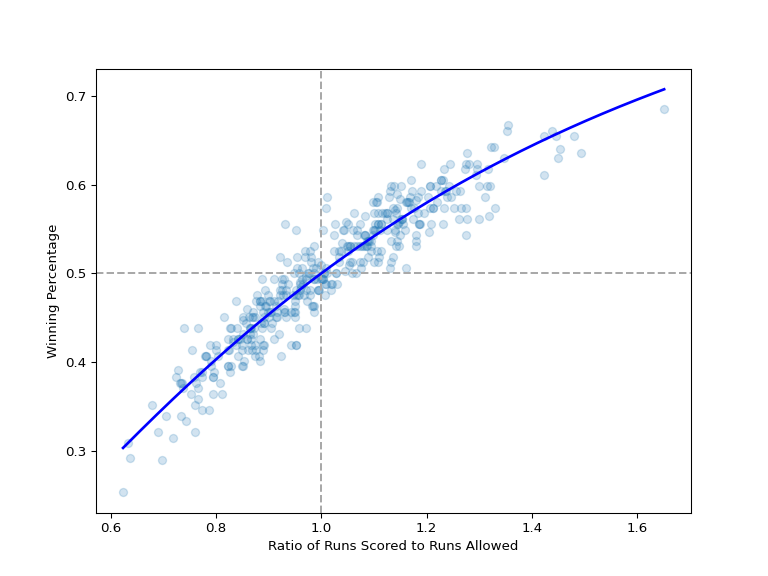

#### 2-1.2

## R

``` r
# Prepare data for logistic regression
TeamRuns_logit <- Teams %>%
  filter(
    yearID >= 2010,
    yearID <= 2025,
    yearID != 2020
  ) %>%
  rename(RS = R) %>%
  mutate(
    WPct = W / (W + L),
    run_ratio = RS / RA,
    log_run_ratio = log(run_ratio)
  ) %>%
  filter(
    RS > 0,
    RA > 0,
    is.finite(WPct),
    is.finite(log_run_ratio)
  )

# Fit logistic regression model without intercept
logit_fit <- glm(
  cbind(W, L) ~ 0 + log_run_ratio,
  data = TeamRuns_logit,
  family = binomial
)

summary(logit_fit)
```


    Call:
    glm(formula = cbind(W, L) ~ 0 + log_run_ratio, family = binomial, 
        data = TeamRuns_logit)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    log_run_ratio  1.75320    0.04562   38.43   <2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.54  on 450  degrees of freedom
    Residual deviance:  180.26  on 449  degrees of freedom
    AIC: 2665.5

    Number of Fisher Scoring iterations: 3

``` r
# Point estimate and 95% confidence interval for beta_1
beta1_hat <- coef(logit_fit)["log_run_ratio"]
beta1_ci <- confint(logit_fit)

cat("Estimated beta_1 =", round(beta1_hat, 4), "\n")
```

    Estimated beta_1 = 1.7532 

``` r
cat(
  "95% CI = (",
  round(beta1_ci[1], 4), ", ",
  round(beta1_ci[2], 4), ")\n",
  sep = ""
)
```

    95% CI = (1.6639, 1.8427)

``` r
# Compare with k from the nonlinear model in Question 1
k_hat <- coef(fit)["k"]
k_ci <- confint(fit)

comparison <- data.frame(
  model = c("Nonlinear model", "Logistic regression model"),
  estimate = c(k_hat, beta1_hat),
  conf_low = c(k_ci[1], beta1_ci[1]),
  conf_high = c(k_ci[2], beta1_ci[2])
)

comparison
```

                                      model estimate conf_low conf_high
    k                       Nonlinear model 1.752794 1.695234  1.810559
    log_run_ratio Logistic regression model 1.753203 1.663879  1.842698

## Python

``` python
# Prepare data for logistic regression
Teams = pl.from_pandas(pylahman.Teams())

TeamRuns_logit = (
    Teams
    .filter(
        (pl.col("yearID") >= 2010) &
        (pl.col("yearID") <= 2025) &
        (pl.col("yearID") != 2020)
    )
    .rename({"R": "RS"})
    .with_columns([
        (pl.col("W") / (pl.col("W") + pl.col("L"))).alias("WPct"),
        (pl.col("RS") / pl.col("RA")).alias("run_ratio"),
        (pl.col("RS") / pl.col("RA")).log().alias("log_run_ratio")
    ])
    .filter(
        (pl.col("RS") > 0) &
        (pl.col("RA") > 0) &
        pl.col("WPct").is_finite() &
        pl.col("log_run_ratio").is_finite()
    )
)

df = TeamRuns_logit.to_pandas()

# Fit logistic regression without intercept
# W wins out of W + L games
X = df[["log_run_ratio"]]
y = np.column_stack([df["W"], df["L"]])

logit_fit = sm.GLM(
    y,
    X,
    family=sm.families.Binomial()
).fit()

print(logit_fit.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:           ['y1', 'y2']   No. Observations:                  420
    Model:                            GLM   Df Residuals:                      419
    Model Family:                Binomial   Df Model:                            0
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1241.6
    Date:                Fri, 12 Jun 2026   Deviance:                       165.67
    Time:                        05:23:35   Pearson chi2:                     165.
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9672
    Covariance Type:            nonrobust                                         
    =================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
    ---------------------------------------------------------------------------------
    log_run_ratio     1.7608      0.047     37.356      0.000       1.668       1.853
    =================================================================================

``` python
# Point estimate and 95% confidence interval
beta1_hat = logit_fit.params["log_run_ratio"]
beta1_ci = logit_fit.conf_int().loc["log_run_ratio"]

print(f"Estimated beta_1 = {beta1_hat:.4f}")
```

    Estimated beta_1 = 1.7608

``` python
print(f"95% CI = ({beta1_ci[0]:.4f}, {beta1_ci[1]:.4f})")
```

    95% CI = (1.6684, 1.8532)

``` python
# Compare with k from Question 1
comparison = pd.DataFrame({
    "model": [
        "Nonlinear model",
        "Logistic regression model"
    ],
    "estimate": [
        k_hat,
        beta1_hat
    ],
    "conf_low": [
        ci_lower,
        beta1_ci[0]
    ],
    "conf_high": [
        ci_upper,
        beta1_ci[1]
    ]
})

print(comparison)
```

                           model  estimate  conf_low  conf_high
    0            Nonlinear model  1.761041  1.702121   1.819961
    1  Logistic regression model  1.760815  1.668430   1.853200

The two estimates and confidence intervals are nearly identical,
confirming that $\beta_1$ has essentially the same interpretation as
$k$. Both models suggest an exponent of approximately 1.75, which is
lower than the classical Bill James value of 2.

#### 2-1.3

## R

``` r
# (i) Residual deviance compared with chi-square distribution
res_dev <- deviance(logit_fit)
res_df <- df.residual(logit_fit)
res_pval <- 1 - pchisq(res_dev, df = res_df)

cat("Residual deviance =", round(res_dev, 4), "\n")
```

    Residual deviance = 180.2632 

``` r
cat("Residual degrees of freedom =", res_df, "\n")
```

    Residual degrees of freedom = 449 

``` r
cat("Chi-square p-value =", round(res_pval, 4), "\n")
```

    Chi-square p-value = 1 

``` r
# Add diagnostic quantities
TeamRuns_logit <- TeamRuns_logit %>%
  mutate(
    eta = predict(logit_fit, type = "link"),
    dev_resid = residuals(logit_fit, type = "deviance"),
    pred_WPct = predict(logit_fit, type = "response")
  )

# (ii) Deviance residuals vs linear predictors
ggplot(TeamRuns_logit, aes(x = eta, y = dev_resid)) +
  geom_point(alpha = 0.5) +
  geom_hline(
    yintercept = 0,
    linetype = 2,
    color = "darkgray"
  ) +
  xlab(expression(hat(eta))) +
  ylab("Deviance residuals")
```

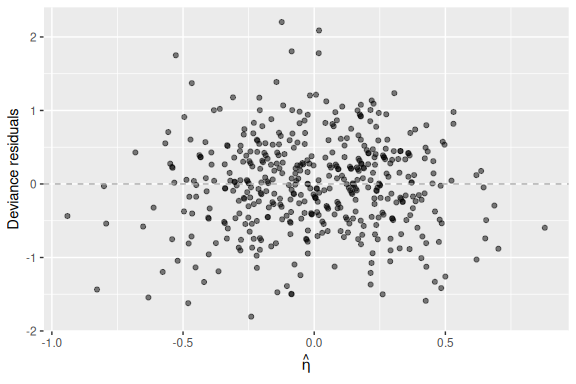

``` r
# (iii) Observed WPct vs predicted WPct
ggplot(TeamRuns_logit, aes(x = pred_WPct, y = WPct)) +
  geom_point(alpha = 0.5) +
  geom_abline(
    slope = 1,
    intercept = 0,
    linetype = 2,
    color = "darkgray"
  ) +
  xlab("Predicted WPct") +
  ylab("Observed WPct")
```

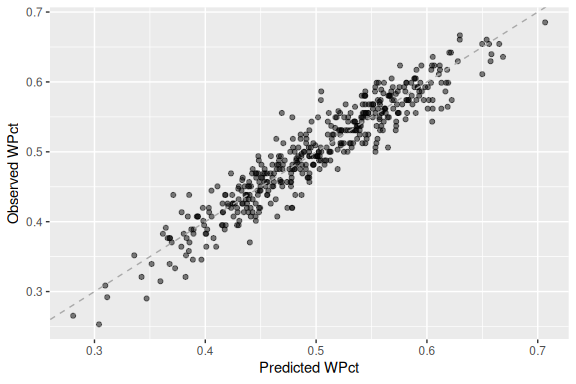

## Python

``` python
# (i) Residual deviance compared with chi-square distribution

res_dev = logit_fit.deviance
res_df = logit_fit.df_resid
res_pval = 1 - chi2.cdf(res_dev, df=res_df)

print(f"Residual deviance = {res_dev:.4f}")
```

    Residual deviance = 165.6734

``` python
print(f"Residual degrees of freedom = {res_df:.0f}")
```

    Residual degrees of freedom = 419

``` python
print(f"Chi-square p-value = {res_pval:.4f}")
```

    Chi-square p-value = 1.0000

``` python
# Add diagnostic quantities

df["eta"] = logit_fit.predict(linear=True)
df["pred_WPct"] = logit_fit.predict()

# Deviance residuals
df["dev_resid"] = logit_fit.resid_deviance

# (ii) Deviance residuals vs linear predictors

plt.figure(figsize=(8, 6))
plt.scatter(
    df["eta"],
    df["dev_resid"],
    alpha=0.5
)
plt.axhline(
    y=0,
    linestyle="--",
    color="gray"
)
plt.xlabel(r"$\hat{\eta}$")
plt.ylabel("Deviance residuals")
plt.show()
```

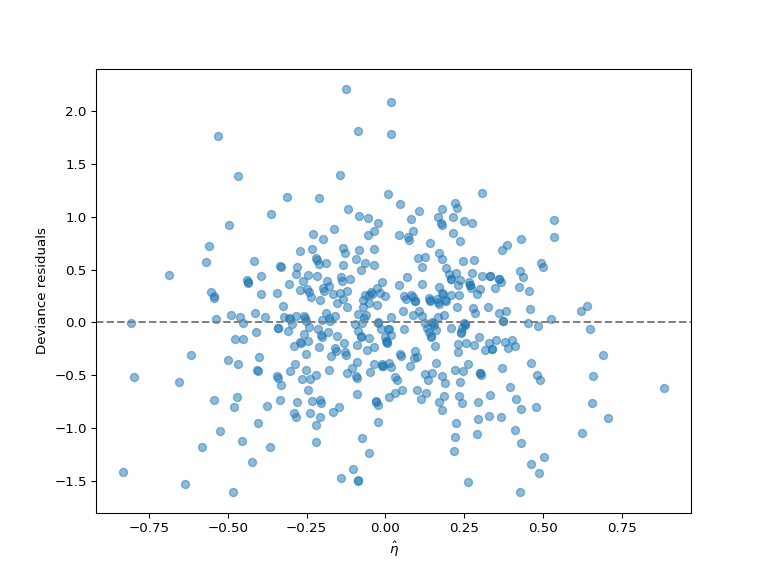

``` python
# (iii) Observed WPct vs predicted WPct

plt.figure(figsize=(8, 6))
plt.scatter(
    df["pred_WPct"],
    df["WPct"],
    alpha=0.5
)

plt.plot(
    [df["pred_WPct"].min(), df["pred_WPct"].max()],
    [df["pred_WPct"].min(), df["pred_WPct"].max()],
    linestyle="--",
    color="gray"
)

plt.xlabel("Predicted WPct")
plt.ylabel("Observed WPct")
plt.show()
```

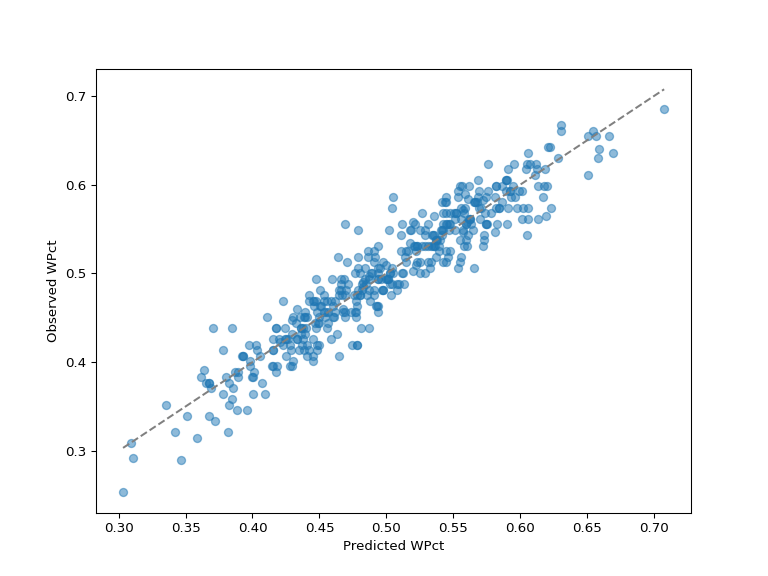

1.  The residual deviance is 180.26 with 449 degrees of freedom. Under
    the fitted logistic regression model, the residual deviance
    approximately follows a $\chi_{449}^2$ distribution. The
    corresponding p-value is approximately 1.00, which is much larger
    than 0.05. Therefore, we fail to reject the null hypothesis that the
    model fits the data adequately. There is no evidence of lack of fit,
    suggesting that the logistic regression model provides a
    satisfactory fit to the data.

2.  The deviance residuals are centered around zero and do not exhibit
    any systematic pattern, indicating that the model assumptions appear
    reasonable.

3.  Since the points are tightly clustered around the 45-degree line
    with only minor deviations, the model appears to predict winning
    percentage accurately.

#### 2-1.4

## R

``` r
# Prepare data
TeamRuns_logRSRA <- Teams %>%
  filter(
    yearID >= 2010,
    yearID <= 2025,
    yearID != 2020
  ) %>%
  rename(RS = R) %>%
  mutate(
    WPct = W / (W + L),
    log_RS = log(RS),
    log_RA = log(RA)
  ) %>%
  filter(
    RS > 0,
    RA > 0,
    is.finite(WPct),
    is.finite(log_RS),
    is.finite(log_RA)
  )

# Fit logistic regression model without intercept
# logit(WPct) = beta_RS log(RS) + beta_RA log(RA)
logRSRA_fit <- glm(
  cbind(W, L) ~ 0 + log_RS + log_RA,
  data = TeamRuns_logRSRA,
  family = binomial
)

summary(logRSRA_fit)
```


    Call:
    glm(formula = cbind(W, L) ~ 0 + log_RS + log_RA, family = binomial, 
        data = TeamRuns_logRSRA)

    Coefficients:
           Estimate Std. Error z value Pr(>|z|)    
    log_RS  1.75315    0.04562   38.43   <2e-16 ***
    log_RA -1.75356    0.04563  -38.43   <2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.54  on 450  degrees of freedom
    Residual deviance:  180.13  on 448  degrees of freedom
    AIC: 2667.4

    Number of Fisher Scoring iterations: 3

``` r
# Point estimates and 95% confidence intervals
coef_logRSRA <- coef(logRSRA_fit)
ci_logRSRA <- confint(logRSRA_fit)

coef_table <- data.frame(
  parameter = names(coef_logRSRA),
  estimate = coef_logRSRA,
  conf_low = ci_logRSRA[, 1],
  conf_high = ci_logRSRA[, 2]
)

coef_table
```

           parameter  estimate  conf_low conf_high
    log_RS    log_RS  1.753153  1.663826  1.842650
    log_RA    log_RA -1.753561 -1.843080 -1.664214

``` r
# Compare Q1, Q2, and Q4
comparison_q4 <- data.frame(
  parameter = c(
    "Q1: k",
    "Q2: beta_1",
    "Q4: beta_RS",
    "Q4: beta_RA"
  ),
  estimate = c(
    k_hat,
    beta1_hat,
    coef_logRSRA["log_RS"],
    coef_logRSRA["log_RA"]
  ),
  conf_low = c(
    k_ci[1],
    beta1_ci[1],
    ci_logRSRA["log_RS", 1],
    ci_logRSRA["log_RA", 1]
  ),
  conf_high = c(
    k_ci[2],
    beta1_ci[2],
    ci_logRSRA["log_RS", 2],
    ci_logRSRA["log_RA", 2]
  )
)

comparison_q4
```

                    parameter  estimate  conf_low conf_high
    k                   Q1: k  1.752794  1.695234  1.810559
    log_run_ratio  Q2: beta_1  1.753203  1.663879  1.842698
    log_RS        Q4: beta_RS  1.753153  1.663826  1.842650
    log_RA        Q4: beta_RA -1.753561 -1.843080 -1.664214

## Python

``` python
# Prepare data
TeamRuns_logRSRA = (
    Teams
    .filter(
        (pl.col("yearID") >= 2010) &
        (pl.col("yearID") <= 2025) &
        (pl.col("yearID") != 2020)
    )
    .rename({"R": "RS"})
    .with_columns([
        (pl.col("W") / (pl.col("W") + pl.col("L"))).alias("WPct"),
        pl.col("RS").log().alias("log_RS"),
        pl.col("RA").log().alias("log_RA")
    ])
    .filter(
        (pl.col("RS") > 0) &
        (pl.col("RA") > 0) &
        pl.col("WPct").is_finite() &
        pl.col("log_RS").is_finite() &
        pl.col("log_RA").is_finite()
    )
)

df_q4 = TeamRuns_logRSRA.to_pandas()

# Fit logistic regression model without intercept
# logit(WPct) = beta_RS log(RS) + beta_RA log(RA)

X = df_q4[["log_RS", "log_RA"]]
y = np.column_stack([df_q4["W"], df_q4["L"]])

logRSRA_fit = sm.GLM(
    y,
    X,
    family=sm.families.Binomial()
).fit()

print(logRSRA_fit.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:           ['y1', 'y2']   No. Observations:                  420
    Model:                            GLM   Df Residuals:                      418
    Model Family:                Binomial   Df Model:                            1
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1241.6
    Date:                Fri, 12 Jun 2026   Deviance:                       165.58
    Time:                        05:23:36   Pearson chi2:                     165.
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9672
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    log_RS         1.7607      0.047     37.354      0.000       1.668       1.853
    log_RA        -1.7611      0.047    -37.354      0.000      -1.854      -1.669
    ==============================================================================

``` python
# Point estimates and 95% confidence intervals
coef_logRSRA = logRSRA_fit.params
ci_logRSRA = logRSRA_fit.conf_int()

coef_table = pd.DataFrame({
    "parameter": coef_logRSRA.index,
    "estimate": coef_logRSRA.values,
    "conf_low": ci_logRSRA[0].values,
    "conf_high": ci_logRSRA[1].values
})

print("\nCoefficient estimates:")
```


    Coefficient estimates:

``` python
print(coef_table)
```

      parameter  estimate  conf_low  conf_high
    0    log_RS  1.760742  1.668356   1.853129
    1    log_RA -1.761107 -1.853512  -1.668703

``` python
comparison_q4 = pd.DataFrame({
    "parameter": [
        "Q1: k",
        "Q2: beta_1",
        "Q4: beta_RS",
        "Q4: beta_RA"
    ],
    "estimate": [
        k_hat,
        beta1_hat,
        coef_logRSRA["log_RS"],
        coef_logRSRA["log_RA"]
    ],
    "conf_low": [
        ci_lower,
        beta1_ci[0],
        ci_logRSRA.loc["log_RS", 0],
        ci_logRSRA.loc["log_RA", 0]
    ],
    "conf_high": [
        ci_upper,
        beta1_ci[1],
        ci_logRSRA.loc["log_RS", 1],
        ci_logRSRA.loc["log_RA", 1]
    ]
})

print("\nComparison of Q1, Q2, and Q4:")
```


    Comparison of Q1, Q2, and Q4:

``` python
print(comparison_q4)
```

         parameter  estimate  conf_low  conf_high
    0        Q1: k  1.761041  1.702121   1.819961
    1   Q2: beta_1  1.760815  1.668430   1.853200
    2  Q4: beta_RS  1.760742  1.668356   1.853129
    3  Q4: beta_RA -1.761107 -1.853512  -1.668703

The fitted model uses log(RS) and log(RA) separately as predictors.
Since

$$ \log(RS/RA)=\log(RS)-\log(RA), $$

the model in Q2 implies coefficients of equal magnitude and opposite
sign for log(RS) and log(RA). The estimated coefficient for log(RS) is
close to the estimates of k from Q1 and $\beta_1$ from Q2, while the
coefficient for log(RA) is approximately their negative. Therefore, the
model in Q4 yields essentially the same relationship between winning
percentage and the ratio of runs scored to runs allowed as the models in
Q1, Q2. This suggests that the three models are largely equivalent
representations of the same underlying relationship.

## 문제 2-2

`WPct`를 반응변수로, `logRS`, `logRA`, `H`, `X2B`, `X3B`, `HR`, `BB`,
`SO`, `CS`, `HBP`, `SF`, `ERA`, `CG`, `SHO`, `IPouts`, `HA`, `HRA`,
`BBA`, `SOA`, `E`, `DP`, `FP`, `SV`를 설명변수로 하는 절편항이 있는
로지스틱 회귀 모형을 적합하고 AIC를 기준으로 하는 단계별(stepwise)
변수선택을 적용하라. 변수선택 후 남은 변수들을 모두 모형에 남길지 일부를
제거할지 다시 판단하라. 최종적으로 선택된 모형을 문제1의 모형과
비교하라.

### 답안

## R

``` r
TeamRuns_full <- Teams %>%
  filter(
    yearID >= 2010,
    yearID <= 2025,
    yearID != 2020
  ) %>%
  rename(RS = R) %>%
  mutate(
    WPct = W / (W + L),
    logRS = log(RS),
    logRA = log(RA)
  ) %>%
  select(
    yearID, teamID, lgID,
    W, L, WPct,
    logRS, logRA,
    H, X2B, X3B, HR, BB, SO, CS, HBP, SF,
    ERA, CG, SHO, IPouts, HA, HRA, BBA, SOA,
    E, DP, FP, SV
  ) %>%
  filter(
    if_all(everything(), ~ !is.na(.))
  )

# Full model with intercept
full_fit <- glm(
  cbind(W, L) ~ logRS + logRA + H + X2B + X3B + HR + BB + SO +
    CS + HBP + SF + ERA + CG + SHO + IPouts + HA + HRA +
    BBA + SOA + E + DP + FP + SV,
  data = TeamRuns_full,
  family = binomial
)

summary(full_fit)
```


    Call:
    glm(formula = cbind(W, L) ~ logRS + logRA + H + X2B + X3B + HR + 
        BB + SO + CS + HBP + SF + ERA + CG + SHO + IPouts + HA + 
        HRA + BBA + SOA + E + DP + FP + SV, family = binomial, data = TeamRuns_full)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -6.295e+00  2.164e+01  -0.291   0.7712    
    logRS        1.798e+00  2.399e-01   7.494 6.70e-14 ***
    logRA       -8.176e-01  4.583e-01  -1.784   0.0744 .  
    H           -1.988e-04  2.253e-04  -0.882   0.3776    
    X2B         -2.403e-05  4.222e-04  -0.057   0.9546    
    X3B         -5.939e-04  1.037e-03  -0.573   0.5669    
    HR          -2.086e-04  4.590e-04  -0.454   0.6495    
    BB          -2.100e-04  1.939e-04  -1.083   0.2788    
    SO          -8.226e-05  9.049e-05  -0.909   0.3633    
    CS          -1.054e-03  8.776e-04  -1.201   0.2297    
    HBP          1.106e-04  5.563e-04   0.199   0.8424    
    SF          -7.419e-04  1.147e-03  -0.647   0.5177    
    ERA         -3.388e-03  1.137e-01  -0.030   0.9762    
    CG           5.981e-03  3.710e-03   1.612   0.1069    
    SHO          4.140e-03  2.592e-03   1.597   0.1102    
    IPouts       4.424e-04  2.735e-04   1.618   0.1057    
    HA          -3.322e-04  2.455e-04  -1.353   0.1760    
    HRA         -6.512e-04  4.947e-04  -1.316   0.1880    
    BBA         -1.764e-04  2.063e-04  -0.855   0.3925    
    SOA          4.445e-05  1.011e-04   0.440   0.6601    
    E           -3.508e-04  3.567e-03  -0.098   0.9217    
    DP           3.774e-04  5.431e-04   0.695   0.4871    
    FP          -1.389e+00  2.166e+01  -0.064   0.9489    
    SV           1.106e-02  1.404e-03   7.880 3.28e-15 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.541  on 449  degrees of freedom
    Residual deviance:   95.956  on 426  degrees of freedom
    AIC: 2627.2

    Number of Fisher Scoring iterations: 3

``` r
AIC(full_fit)
```

    [1] 2627.2

``` r
# Stepwise variable selection by AIC
step_fit <- step(
  full_fit,
  direction = "both",
  trace = TRUE
)
```

    Start:  AIC=2627.2
    cbind(W, L) ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + 
        CS + HBP + SF + ERA + CG + SHO + IPouts + HA + HRA + BBA + 
        SOA + E + DP + FP + SV

             Df Deviance    AIC
    - ERA     1   95.956 2625.2
    - X2B     1   95.959 2625.2
    - FP      1   95.960 2625.2
    - E       1   95.965 2625.2
    - HBP     1   95.995 2625.2
    - SOA     1   96.149 2625.4
    - HR      1   96.162 2625.4
    - X3B     1   96.283 2625.5
    - SF      1   96.374 2625.6
    - DP      1   96.438 2625.7
    - BBA     1   96.687 2625.9
    - H       1   96.734 2626.0
    - SO      1   96.782 2626.0
    - BB      1   97.129 2626.4
    - CS      1   97.398 2626.6
    - HRA     1   97.689 2626.9
    - HA      1   97.786 2627.0
    <none>        95.956 2627.2
    - SHO     1   98.507 2627.8
    - CG      1   98.556 2627.8
    - IPouts  1   98.573 2627.8
    - logRA   1   99.138 2628.4
    - logRS   1  152.176 2681.4
    - SV      1  158.117 2687.4

    Step:  AIC=2625.2
    cbind(W, L) ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + 
        CS + HBP + SF + CG + SHO + IPouts + HA + HRA + BBA + SOA + 
        E + DP + FP + SV

             Df Deviance    AIC
    - X2B     1   95.960 2623.2
    - FP      1   95.961 2623.2
    - E       1   95.966 2623.2
    - HBP     1   95.996 2623.2
    - SOA     1   96.150 2623.4
    - HR      1   96.167 2623.4
    - X3B     1   96.296 2623.5
    - SF      1   96.375 2623.6
    - DP      1   96.441 2623.7
    - H       1   96.735 2624.0
    - BBA     1   96.767 2624.0
    - SO      1   96.782 2624.0
    - BB      1   97.130 2624.4
    - CS      1   97.404 2624.7
    - HRA     1   97.954 2625.2
    <none>        95.956 2625.2
    - HA      1   98.019 2625.3
    - SHO     1   98.514 2625.8
    - CG      1   98.556 2625.8
    - IPouts  1   99.236 2626.5
    + ERA     1   95.956 2627.2
    - logRA   1  107.751 2635.0
    - logRS   1  152.399 2679.6
    - SV      1  158.914 2686.2

    Step:  AIC=2623.2
    cbind(W, L) ~ logRS + logRA + H + X3B + HR + BB + SO + CS + HBP + 
        SF + CG + SHO + IPouts + HA + HRA + BBA + SOA + E + DP + 
        FP + SV

             Df Deviance    AIC
    - FP      1   95.964 2621.2
    - E       1   95.970 2621.2
    - HBP     1   96.001 2621.2
    - SOA     1   96.152 2621.4
    - HR      1   96.173 2621.4
    - X3B     1   96.296 2621.5
    - SF      1   96.376 2621.6
    - DP      1   96.456 2621.7
    - BBA     1   96.768 2622.0
    - H       1   96.807 2622.1
    - SO      1   96.810 2622.1
    - BB      1   97.132 2622.4
    - CS      1   97.407 2622.7
    - HRA     1   97.955 2623.2
    <none>        95.960 2623.2
    - HA      1   98.049 2623.3
    - SHO     1   98.548 2623.8
    - CG      1   98.559 2623.8
    - IPouts  1   99.243 2624.5
    + X2B     1   95.956 2625.2
    + ERA     1   95.959 2625.2
    - logRA   1  107.754 2633.0
    - logRS   1  158.132 2683.4
    - SV      1  159.052 2684.3

    Step:  AIC=2621.21
    cbind(W, L) ~ logRS + logRA + H + X3B + HR + BB + SO + CS + HBP + 
        SF + CG + SHO + IPouts + HA + HRA + BBA + SOA + E + DP + 
        SV

             Df Deviance    AIC
    - HBP     1   96.006 2619.2
    - E       1   96.011 2619.3
    - SOA     1   96.180 2619.4
    - HR      1   96.183 2619.4
    - X3B     1   96.320 2619.6
    - SF      1   96.376 2619.6
    - DP      1   96.465 2619.7
    - BBA     1   96.772 2620.0
    - SO      1   96.811 2620.1
    - H       1   96.817 2620.1
    - BB      1   97.169 2620.4
    - CS      1   97.416 2620.7
    - HRA     1   97.963 2621.2
    <none>        95.964 2621.2
    - HA      1   98.061 2621.3
    - SHO     1   98.568 2621.8
    - CG      1   98.579 2621.8
    - IPouts  1   99.620 2622.9
    + FP      1   95.960 2623.2
    + X2B     1   95.961 2623.2
    + ERA     1   95.963 2623.2
    - logRA   1  107.761 2631.0
    - logRS   1  158.390 2681.6
    - SV      1  159.103 2682.3

    Step:  AIC=2619.25
    cbind(W, L) ~ logRS + logRA + H + X3B + HR + BB + SO + CS + SF + 
        CG + SHO + IPouts + HA + HRA + BBA + SOA + E + DP + SV

             Df Deviance    AIC
    - E       1   96.050 2617.3
    - SOA     1   96.240 2617.5
    - HR      1   96.256 2617.5
    - X3B     1   96.403 2617.7
    - SF      1   96.444 2617.7
    - DP      1   96.513 2617.8
    - BBA     1   96.820 2618.1
    - SO      1   96.852 2618.1
    - H       1   97.010 2618.3
    - BB      1   97.268 2618.5
    - CS      1   97.425 2618.7
    - HRA     1   97.998 2619.2
    <none>        96.006 2619.2
    - HA      1   98.151 2619.4
    - CG      1   98.584 2619.8
    - SHO     1   98.646 2619.9
    - IPouts  1   99.686 2620.9
    + HBP     1   95.964 2621.2
    + X2B     1   96.000 2621.2
    + FP      1   96.001 2621.2
    + ERA     1   96.005 2621.2
    - logRA   1  107.763 2629.0
    - SV      1  159.458 2680.7
    - logRS   1  164.225 2685.5

    Step:  AIC=2617.29
    cbind(W, L) ~ logRS + logRA + H + X3B + HR + BB + SO + CS + SF + 
        CG + SHO + IPouts + HA + HRA + BBA + SOA + DP + SV

             Df Deviance    AIC
    - SOA     1   96.287 2615.5
    - HR      1   96.306 2615.6
    - X3B     1   96.454 2615.7
    - SF      1   96.472 2615.7
    - DP      1   96.539 2615.8
    - BBA     1   96.865 2616.1
    - SO      1   96.927 2616.2
    - H       1   97.094 2616.3
    - BB      1   97.350 2616.6
    - CS      1   97.531 2616.8
    - HRA     1   98.004 2617.2
    <none>        96.050 2617.3
    - HA      1   98.182 2617.4
    - CG      1   98.595 2617.8
    - SHO     1   98.747 2618.0
    - IPouts  1   99.707 2618.9
    + E       1   96.006 2619.2
    + HBP     1   96.011 2619.3
    + FP      1   96.012 2619.3
    + X2B     1   96.041 2619.3
    + ERA     1   96.044 2619.3
    - logRA   1  108.308 2627.6
    - SV      1  159.462 2678.7
    - logRS   1  165.106 2684.3

    Step:  AIC=2615.53
    cbind(W, L) ~ logRS + logRA + H + X3B + HR + BB + SO + CS + SF + 
        CG + SHO + IPouts + HA + HRA + BBA + DP + SV

             Df Deviance    AIC
    - HR      1   96.516 2613.8
    - DP      1   96.621 2613.9
    - X3B     1   96.700 2613.9
    - SF      1   96.746 2614.0
    - SO      1   97.012 2614.3
    - BBA     1   97.068 2614.3
    - H       1   97.227 2614.5
    - BB      1   97.616 2614.9
    - HRA     1   98.061 2615.3
    - CS      1   98.104 2615.3
    <none>        96.287 2615.5
    - CG      1   98.678 2615.9
    - SHO     1   99.092 2616.3
    - HA      1   99.224 2616.5
    + SOA     1   96.050 2617.3
    + HBP     1   96.230 2617.5
    + E       1   96.240 2617.5
    + FP      1   96.252 2617.5
    + ERA     1   96.281 2617.5
    + X2B     1   96.281 2617.5
    - IPouts  1  100.334 2617.6
    - logRA   1  108.508 2625.8
    - SV      1  160.319 2677.6
    - logRS   1  165.544 2682.8

    Step:  AIC=2613.76
    cbind(W, L) ~ logRS + logRA + H + X3B + BB + SO + CS + SF + CG + 
        SHO + IPouts + HA + HRA + BBA + DP + SV

             Df Deviance    AIC
    - X3B     1   96.781 2612.0
    - DP      1   96.839 2612.1
    - SF      1   96.876 2612.1
    - H       1   97.285 2612.5
    - BBA     1   97.334 2612.6
    - SO      1   97.538 2612.8
    - BB      1   97.693 2612.9
    - CS      1   98.225 2613.5
    <none>        96.516 2613.8
    - HRA     1   98.601 2613.8
    - CG      1   98.853 2614.1
    - SHO     1   99.368 2614.6
    - HA      1   99.531 2614.8
    + HR      1   96.287 2615.5
    + SOA     1   96.306 2615.6
    - IPouts  1  100.414 2615.7
    + HBP     1   96.427 2615.7
    + E       1   96.463 2615.7
    + FP      1   96.478 2615.7
    + X2B     1   96.512 2615.8
    + ERA     1   96.513 2615.8
    - logRA   1  108.627 2623.9
    - SV      1  160.682 2675.9
    - logRS   1  215.370 2730.6

    Step:  AIC=2612.03
    cbind(W, L) ~ logRS + logRA + H + BB + SO + CS + SF + CG + SHO + 
        IPouts + HA + HRA + BBA + DP + SV

             Df Deviance    AIC
    - DP      1   97.119 2610.4
    - SF      1   97.235 2610.5
    - BBA     1   97.637 2610.9
    - H       1   97.805 2611.1
    - BB      1   97.959 2611.2
    - SO      1   98.053 2611.3
    - HRA     1   98.781 2612.0
    <none>        96.781 2612.0
    - CS      1   98.904 2612.2
    - CG      1   99.050 2612.3
    - SHO     1   99.588 2612.8
    - HA      1  100.077 2613.3
    + X3B     1   96.516 2613.8
    + SOA     1   96.555 2613.8
    + HBP     1   96.660 2613.9
    + HR      1   96.700 2613.9
    + E       1   96.723 2614.0
    + FP      1   96.744 2614.0
    + X2B     1   96.777 2614.0
    + ERA     1   96.781 2614.0
    - IPouts  1  100.888 2614.1
    - logRA   1  108.737 2622.0
    - SV      1  161.221 2674.5
    - logRS   1  217.373 2730.6

    Step:  AIC=2610.36
    cbind(W, L) ~ logRS + logRA + H + BB + SO + CS + SF + CG + SHO + 
        IPouts + HA + HRA + BBA + SV

             Df Deviance    AIC
    - SF      1   97.579 2608.8
    - BBA     1   97.780 2609.0
    - H       1   98.123 2609.4
    - SO      1   98.269 2609.5
    - BB      1   98.433 2609.7
    <none>        97.119 2610.4
    - HRA     1   99.144 2610.4
    - CS      1   99.187 2610.4
    - CG      1   99.706 2610.9
    - SHO     1   99.898 2611.1
    - HA      1  100.102 2611.3
    + DP      1   96.781 2612.0
    + X3B     1   96.839 2612.1
    + HBP     1   96.999 2612.2
    + SOA     1   97.043 2612.3
    + HR      1   97.047 2612.3
    + E       1   97.081 2612.3
    + FP      1   97.088 2612.3
    - IPouts  1  101.089 2612.3
    + ERA     1   97.118 2612.4
    + X2B     1   97.119 2612.4
    - logRA   1  110.462 2621.7
    - SV      1  161.631 2672.9
    - logRS   1  219.194 2730.4

    Step:  AIC=2608.82
    cbind(W, L) ~ logRS + logRA + H + BB + SO + CS + CG + SHO + IPouts + 
        HA + HRA + BBA + SV

             Df Deviance    AIC
    - BBA     1   98.130 2607.4
    - SO      1   98.449 2607.7
    - H       1   98.565 2607.8
    - BB      1   99.032 2608.3
    - HRA     1   99.335 2608.6
    <none>        97.579 2608.8
    - CS      1   99.774 2609.0
    - CG      1  100.315 2609.6
    - HA      1  100.322 2609.6
    - SHO     1  100.325 2609.6
    + SF      1   97.119 2610.4
    + X3B     1   97.202 2610.4
    + DP      1   97.235 2610.5
    - IPouts  1  101.396 2610.6
    + HBP     1   97.417 2610.7
    + SOA     1   97.475 2610.7
    + E       1   97.557 2610.8
    + FP      1   97.559 2610.8
    + HR      1   97.565 2610.8
    + ERA     1   97.576 2610.8
    + X2B     1   97.578 2610.8
    - logRA   1  111.864 2621.1
    - SV      1  162.810 2672.1
    - logRS   1  220.710 2729.9

    Step:  AIC=2607.37
    cbind(W, L) ~ logRS + logRA + H + BB + SO + CS + CG + SHO + IPouts + 
        HA + HRA + SV

             Df Deviance    AIC
    - SO      1   98.976 2606.2
    - H       1   99.290 2606.5
    - HRA     1   99.513 2606.8
    - BB      1   99.646 2606.9
    <none>        98.130 2607.4
    - HA      1  100.322 2607.6
    - CS      1  100.605 2607.8
    - SHO     1  101.004 2608.2
    - CG      1  101.178 2608.4
    + BBA     1   97.579 2608.8
    - IPouts  1  101.708 2608.9
    + X3B     1   97.736 2609.0
    + SF      1   97.780 2609.0
    + HBP     1   97.960 2609.2
    + DP      1   97.973 2609.2
    + SOA     1   98.015 2609.3
    + ERA     1   98.079 2609.3
    + E       1   98.102 2609.3
    + HR      1   98.105 2609.3
    + FP      1   98.108 2609.3
    + X2B     1   98.129 2609.4
    - logRA   1  122.381 2629.6
    - SV      1  163.942 2671.2
    - logRS   1  224.530 2731.8

    Step:  AIC=2606.22
    cbind(W, L) ~ logRS + logRA + H + BB + CS + CG + SHO + IPouts + 
        HA + HRA + SV

             Df Deviance    AIC
    - H       1   99.480 2604.7
    - HRA     1  100.415 2605.7
    - BB      1  100.521 2605.8
    <none>        98.976 2606.2
    - HA      1  100.980 2606.2
    - CS      1  101.204 2606.4
    - SHO     1  101.775 2607.0
    - IPouts  1  101.996 2607.2
    + SO      1   98.130 2607.4
    + X3B     1   98.391 2607.6
    + BBA     1   98.449 2607.7
    + HBP     1   98.798 2608.0
    + HR      1   98.830 2608.1
    + SF      1   98.855 2608.1
    + DP      1   98.886 2608.1
    + E       1   98.903 2608.2
    + FP      1   98.913 2608.2
    + ERA     1   98.943 2608.2
    + SOA     1   98.959 2608.2
    + X2B     1   98.976 2608.2
    - CG      1  103.134 2608.4
    - logRA   1  125.916 2631.2
    - SV      1  164.538 2669.8
    - logRS   1  228.080 2733.3

    Step:  AIC=2604.72
    cbind(W, L) ~ logRS + logRA + BB + CS + CG + SHO + IPouts + HA + 
        HRA + SV

             Df Deviance    AIC
    - BB      1   100.53 2603.8
    - HRA     1   100.64 2603.9
    <none>         99.48 2604.7
    - CS      1   101.78 2605.0
    - IPouts  1   102.09 2605.3
    - SHO     1   102.29 2605.5
    - HA      1   102.32 2605.6
    + X3B     1    98.73 2606.0
    + BBA     1    98.82 2606.1
    + H       1    98.98 2606.2
    + HBP     1    99.13 2606.4
    - CG      1   103.18 2606.4
    + SO      1    99.29 2606.5
    + SF      1    99.30 2606.5
    + DP      1    99.38 2606.6
    + E       1    99.39 2606.6
    + FP      1    99.41 2606.7
    + X2B     1    99.42 2606.7
    + ERA     1    99.43 2606.7
    + SOA     1    99.46 2606.7
    + HR      1    99.48 2606.7
    - logRA   1   126.14 2629.4
    - SV      1   165.54 2668.8
    - logRS   1   411.04 2914.3

    Step:  AIC=2603.78
    cbind(W, L) ~ logRS + logRA + CS + CG + SHO + IPouts + HA + HRA + 
        SV

             Df Deviance    AIC
    - HRA     1   101.75 2603.0
    <none>        100.53 2603.8
    - CS      1   102.70 2603.9
    - IPouts  1   102.73 2604.0
    - HA      1   102.91 2604.2
    - SHO     1   103.17 2604.4
    + BB      1    99.48 2604.7
    + X3B     1    99.91 2605.2
    + BBA     1    99.93 2605.2
    + SO      1   100.02 2605.3
    - CG      1   104.09 2605.3
    + HBP     1   100.25 2605.5
    + SF      1   100.33 2605.6
    + DP      1   100.37 2605.6
    + E       1   100.42 2605.7
    + FP      1   100.44 2605.7
    + SOA     1   100.51 2605.8
    + H       1   100.52 2605.8
    + X2B     1   100.52 2605.8
    + HR      1   100.52 2605.8
    + ERA     1   100.52 2605.8
    - logRA   1   127.17 2628.4
    - SV      1   168.40 2669.7
    - logRS   1   498.13 2999.4

    Step:  AIC=2603
    cbind(W, L) ~ logRS + logRA + CS + CG + SHO + IPouts + HA + SV

             Df Deviance    AIC
    - HA      1   103.18 2602.4
    - CS      1   103.62 2602.9
    <none>        101.75 2603.0
    - IPouts  1   103.86 2603.1
    - SHO     1   104.50 2603.8
    + HRA     1   100.53 2603.8
    + BB      1   100.64 2603.9
    + SO      1   101.03 2604.3
    + X3B     1   101.33 2604.6
    - CG      1   105.43 2604.7
    + DP      1   101.52 2604.8
    + ERA     1   101.54 2604.8
    + HBP     1   101.56 2604.8
    + BBA     1   101.57 2604.8
    + HR      1   101.58 2604.8
    + SF      1   101.70 2604.9
    + H       1   101.74 2605.0
    + SOA     1   101.74 2605.0
    + FP      1   101.75 2605.0
    + E       1   101.75 2605.0
    + X2B     1   101.75 2605.0
    - logRA   1   156.73 2656.0
    - SV      1   168.85 2668.1
    - logRS   1   515.75 3015.0

    Step:  AIC=2602.42
    cbind(W, L) ~ logRS + logRA + CS + CG + SHO + IPouts + SV

             Df Deviance    AIC
    - IPouts  1   104.38 2601.6
    <none>        103.18 2602.4
    - CS      1   105.36 2602.6
    - CG      1   105.69 2602.9
    + HA      1   101.75 2603.0
    + X3B     1   102.36 2603.6
    - SHO     1   106.42 2603.7
    + BB      1   102.51 2603.8
    + HBP     1   102.63 2603.9
    + ERA     1   102.77 2604.0
    + SOA     1   102.81 2604.1
    + HRA     1   102.91 2604.2
    + SO      1   103.00 2604.2
    + H       1   103.02 2604.3
    + SF      1   103.09 2604.3
    + X2B     1   103.12 2604.4
    + E       1   103.13 2604.4
    + FP      1   103.16 2604.4
    + HR      1   103.17 2604.4
    + DP      1   103.17 2604.4
    + BBA     1   103.18 2604.4
    - SV      1   168.88 2666.1
    - logRA   1   246.40 2743.7
    - logRS   1   559.35 3056.6

    Step:  AIC=2601.63
    cbind(W, L) ~ logRS + logRA + CS + CG + SHO + SV

             Df Deviance    AIC
    - CS      1   106.12 2601.4
    <none>        104.38 2601.6
    + IPouts  1   103.18 2602.4
    + ERA     1   103.39 2602.6
    - CG      1   107.43 2602.7
    - SHO     1   107.52 2602.8
    + X3B     1   103.70 2602.9
    + HA      1   103.86 2603.1
    + BB      1   103.86 2603.1
    + HRA     1   103.96 2603.2
    + HBP     1   104.02 2603.3
    + SOA     1   104.05 2603.3
    + SO      1   104.19 2603.4
    + SF      1   104.32 2603.6
    + HR      1   104.37 2603.6
    + FP      1   104.37 2603.6
    + E       1   104.37 2603.6
    + H       1   104.38 2603.6
    + DP      1   104.38 2603.6
    + X2B     1   104.38 2603.6
    + BBA     1   104.38 2603.6
    - SV      1   176.23 2671.5
    - logRA   1   262.76 2758.0
    - logRS   1   579.02 3074.3

    Step:  AIC=2601.36
    cbind(W, L) ~ logRS + logRA + CG + SHO + SV

             Df Deviance    AIC
    <none>        106.12 2601.4
    + CS      1   104.38 2601.6
    - CG      1   108.42 2601.7
    + X3B     1   104.83 2602.1
    + ERA     1   105.24 2602.5
    + SOA     1   105.28 2602.5
    + HA      1   105.30 2602.5
    + IPouts  1   105.36 2602.6
    - SHO     1   109.52 2602.8
    + BB      1   105.69 2602.9
    + HBP     1   105.75 2603.0
    + HRA     1   105.92 2603.2
    + SF      1   105.97 2603.2
    + E       1   106.04 2603.3
    + H       1   106.05 2603.3
    + FP      1   106.06 2603.3
    + SO      1   106.06 2603.3
    + HR      1   106.08 2603.3
    + BBA     1   106.09 2603.3
    + DP      1   106.11 2603.4
    + X2B     1   106.12 2603.4
    - SV      1   176.50 2669.8
    - logRA   1   266.78 2760.0
    - logRS   1   616.29 3109.5

``` r
summary(step_fit)
```


    Call:
    glm(formula = cbind(W, L) ~ logRS + logRA + CG + SHO + SV, family = binomial, 
        data = TeamRuns_full)

    Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -2.694019   0.842064  -3.199  0.00138 ** 
    logRS        1.615284   0.071880  22.472  < 2e-16 ***
    logRA       -1.284160   0.101524 -12.649  < 2e-16 ***
    CG           0.004573   0.003014   1.517  0.12926    
    SHO          0.004669   0.002531   1.845  0.06502 .  
    SV           0.011104   0.001324   8.384  < 2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.54  on 449  degrees of freedom
    Residual deviance:  106.12  on 444  degrees of freedom
    AIC: 2601.4

    Number of Fisher Scoring iterations: 3

``` r
AIC(step_fit)
```

    [1] 2601.364

``` r
# Check whether remaining variables should be kept
drop1(
  step_fit,
  test = "Chisq"
)
```

    Single term deletions

    Model:
    cbind(W, L) ~ logRS + logRA + CG + SHO + SV
           Df Deviance    AIC    LRT Pr(>Chi)    
    <none>      106.12 2601.4                    
    logRS   1   616.29 3109.5 510.17  < 2e-16 ***
    logRA   1   266.78 2760.0 160.66  < 2e-16 ***
    CG      1   108.42 2601.7   2.30  0.12919    
    SHO     1   109.52 2602.8   3.40  0.06502 .  
    SV      1   176.50 2669.8  70.38  < 2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

``` r
# Selected variables
names(coef(step_fit))
```

    [1] "(Intercept)" "logRS"       "logRA"       "CG"          "SHO"        
    [6] "SV"         

``` r
# Final selected model result
final_fit <- step_fit

summary(final_fit)
```


    Call:
    glm(formula = cbind(W, L) ~ logRS + logRA + CG + SHO + SV, family = binomial, 
        data = TeamRuns_full)

    Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -2.694019   0.842064  -3.199  0.00138 ** 
    logRS        1.615284   0.071880  22.472  < 2e-16 ***
    logRA       -1.284160   0.101524 -12.649  < 2e-16 ***
    CG           0.004573   0.003014   1.517  0.12926    
    SHO          0.004669   0.002531   1.845  0.06502 .  
    SV           0.011104   0.001324   8.384  < 2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.54  on 449  degrees of freedom
    Residual deviance:  106.12  on 444  degrees of freedom
    AIC: 2601.4

    Number of Fisher Scoring iterations: 3

``` r
confint(final_fit)
```

                        2.5 %       97.5 %
    (Intercept) -4.3446541956 -1.043776403
    logRS        1.4744832269  1.756251197
    logRA       -1.4832281082 -1.085256034
    CG          -0.0013337379  0.010482423
    SHO         -0.0002905589  0.009629878
    SV           0.0085087527  0.013700148

``` r
# Compare with Problem 2-1 model
# logit_fit is the logistic model from 2-1 Q2:
# cbind(W, L) ~ 0 + log_run_ratio

model_compare <- data.frame(
  model = c("2-1 model", "2-2 stepwise model"),
  AIC = c(
    AIC(logit_fit),
    AIC(final_fit)
  ),
  residual_deviance = c(
    deviance(logit_fit),
    deviance(final_fit)
  ),
  residual_df = c(
    df.residual(logit_fit),
    df.residual(final_fit)
  )
)

model_compare
```

                   model      AIC residual_deviance residual_df
    1          2-1 model 2665.508          180.2632         449
    2 2-2 stepwise model 2601.364          106.1193         444

## Python

``` python
# Prepare data
Teams = (
    pl.from_pandas(pylahman.Teams())
    .rename({
        "R": "RS",
        "2B": "X2B",
        "3B": "X3B"
    })
)

if "IPOuts" in Teams.columns:
    Teams = Teams.rename({"IPOuts": "IPouts"})

TeamRuns_full = (
    Teams
    .filter(
        (pl.col("yearID") >= 2010) &
        (pl.col("yearID") <= 2025) &
        (pl.col("yearID") != 2020)
    )
    .with_columns([
        (pl.col("W") / (pl.col("W") + pl.col("L"))).alias("WPct"),
        pl.col("RS").log().alias("logRS"),
        pl.col("RA").log().alias("logRA")
    ])
    .select([
        "yearID", "teamID", "lgID",
        "W", "L", "WPct",
        "logRS", "logRA",
        "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF",
        "ERA", "CG", "SHO", "IPouts", "HA", "HRA", "BBA", "SOA",
        "E", "DP", "FP", "SV"
    ])
    .drop_nulls()
)

df_full = TeamRuns_full.to_pandas()

# Full model with intercept
predictors = [
    "logRS", "logRA",
    "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF",
    "ERA", "CG", "SHO", "IPouts", "HA", "HRA", "BBA", "SOA",
    "E", "DP", "FP", "SV"
]

X_full = sm.add_constant(df_full[predictors])
y_full = np.column_stack([df_full["W"], df_full["L"]])

full_fit = sm.GLM(
    y_full,
    X_full,
    family=sm.families.Binomial()
).fit()

print(full_fit.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:           ['y1', 'y2']   No. Observations:                  420
    Model:                            GLM   Df Residuals:                      396
    Model Family:                Binomial   Df Model:                           23
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1203.6
    Date:                Fri, 12 Jun 2026   Deviance:                       89.521
    Time:                        05:23:37   Pearson chi2:                     89.5
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9726
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         -5.5146     22.820     -0.242      0.809     -50.240      39.211
    logRS          1.7820      0.248      7.180      0.000       1.296       2.269
    logRA         -0.7694      0.474     -1.624      0.104      -1.698       0.159
    H             -0.0002      0.000     -0.793      0.428      -0.001       0.000
    X2B         8.479e-06      0.000      0.019      0.985      -0.001       0.001
    X3B           -0.0005      0.001     -0.416      0.678      -0.003       0.002
    HR            -0.0002      0.000     -0.389      0.697      -0.001       0.001
    BB            -0.0002      0.000     -0.990      0.322      -0.001       0.000
    SO         -7.811e-05   9.29e-05     -0.841      0.400      -0.000       0.000
    CS            -0.0011      0.001     -1.229      0.219      -0.003       0.001
    HBP         7.042e-05      0.001      0.122      0.903      -0.001       0.001
    SF            -0.0007      0.001     -0.622      0.534      -0.003       0.002
    ERA           -0.0270      0.118     -0.227      0.820      -0.259       0.205
    CG             0.0057      0.004      1.485      0.138      -0.002       0.013
    SHO            0.0038      0.003      1.427      0.154      -0.001       0.009
    IPouts         0.0004      0.000      1.411      0.158      -0.000       0.001
    HA            -0.0003      0.000     -1.312      0.190      -0.001       0.000
    HRA           -0.0006      0.001     -1.256      0.209      -0.002       0.000
    BBA           -0.0002      0.000     -0.766      0.444      -0.001       0.000
    SOA         3.815e-05      0.000      0.367      0.713      -0.000       0.000
    E             -0.0005      0.004     -0.146      0.884      -0.008       0.007
    DP             0.0005      0.001      0.869      0.385      -0.001       0.002
    FP            -2.1151     22.793     -0.093      0.926     -46.788      42.558
    SV             0.0108      0.001      7.466      0.000       0.008       0.014
    ==============================================================================

``` python
print("Full model AIC:", full_fit.aic)
```

    Full model AIC: 2455.1341311534666

``` python
# Stepwise variable selection by AIC
exec("""
def fit_glm(selected_vars):
    X = sm.add_constant(df_full[selected_vars])
    model = sm.GLM(
        y_full,
        X,
        family=sm.families.Binomial()
    ).fit()
    return model


def stepwise_aic(all_vars):
    selected = all_vars.copy()
    current_model = fit_glm(selected)
    current_aic = current_model.aic

    changed = True

    while changed:
        changed = False
        candidates = []

        for var in selected:
            trial_vars = [v for v in selected if v != var]
            trial_model = fit_glm(trial_vars)
            candidates.append({
                "action": "remove",
                "var": var,
                "vars": trial_vars,
                "aic": trial_model.aic,
                "model": trial_model
            })

        remaining = [v for v in all_vars if v not in selected]

        for var in remaining:
            trial_vars = selected + [var]
            trial_model = fit_glm(trial_vars)
            candidates.append({
                "action": "add",
                "var": var,
                "vars": trial_vars,
                "aic": trial_model.aic,
                "model": trial_model
            })

        best = min(candidates, key=lambda x: x["aic"])

        if best["aic"] < current_aic:
            selected = best["vars"]
            current_model = best["model"]
            current_aic = best["aic"]
            changed = True
            print(f"{best['action']} {best['var']}: AIC = {current_aic:.4f}")

    return current_model, selected
""")

step_fit, selected_vars = stepwise_aic(predictors)
```

    remove X2B: AIC = 2453.1345
    remove FP: AIC = 2451.1429
    remove HBP: AIC = 2449.1583
    remove ERA: AIC = 2447.2081
    remove E: AIC = 2445.2571
    remove SOA: AIC = 2443.4407
    remove HR: AIC = 2441.6381
    remove X3B: AIC = 2439.7760
    remove SF: AIC = 2438.1424
    remove DP: AIC = 2436.7735
    remove BBA: AIC = 2435.2209
    remove SO: AIC = 2433.8756
    remove H: AIC = 2432.2624
    remove BB: AIC = 2431.1780
    remove HRA: AIC = 2430.6410
    remove HA: AIC = 2429.7189
    remove IPouts: AIC = 2428.7325
    remove CS: AIC = 2428.5409

``` python
print("\\nSelected variables:")
```

    \nSelected variables:

``` python
print(selected_vars)
```

    ['logRS', 'logRA', 'CG', 'SHO', 'SV']

``` python
print(step_fit.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:           ['y1', 'y2']   No. Observations:                  420
    Model:                            GLM   Df Residuals:                      414
    Model Family:                Binomial   Df Model:                            5
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1208.3
    Date:                Fri, 12 Jun 2026   Deviance:                       98.928
    Time:                        05:23:39   Pearson chi2:                     98.9
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9720
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         -2.4801      0.865     -2.866      0.004      -4.176      -0.784
    logRS          1.6169      0.074     21.973      0.000       1.473       1.761
    logRA         -1.3159      0.105    -12.501      0.000      -1.522      -1.110
    CG             0.0044      0.003      1.435      0.151      -0.002       0.011
    SHO            0.0043      0.003      1.653      0.098      -0.001       0.009
    SV             0.0108      0.001      7.936      0.000       0.008       0.013
    ==============================================================================

``` python
print("Stepwise model AIC:", step_fit.aic)
```

    Stepwise model AIC: 2428.54089768661

``` python
# Drop-one check
drop1_results = []

for var in selected_vars:
    reduced_vars = [v for v in selected_vars if v != var]
    reduced_fit = fit_glm(reduced_vars)

    lrt = reduced_fit.deviance - step_fit.deviance
    pval = 1 - chi2.cdf(lrt, df=1)

    drop1_results.append({
        "variable": var,
        "reduced_deviance": reduced_fit.deviance,
        "reduced_AIC": reduced_fit.aic,
        "LRT": lrt,
        "p_value": pval
    })

drop1_table = pd.DataFrame(drop1_results)

print("\\nDrop-one results:")
```

    \nDrop-one results:

``` python
print(drop1_table)
```

      variable  reduced_deviance  reduced_AIC         LRT       p_value
    0    logRS        586.872603  2914.485777  487.944880  0.000000e+00
    1    logRA        255.876922  2583.490096  156.949198  0.000000e+00
    2       CG        100.988422  2428.601596    2.060698  1.511409e-01
    3      SHO        101.658677  2429.271851    2.730953  9.842053e-02
    4       SV        161.959597  2489.572771   63.031873  1.998401e-15

``` python
# Final selected model
final_fit = step_fit

print(final_fit.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:           ['y1', 'y2']   No. Observations:                  420
    Model:                            GLM   Df Residuals:                      414
    Model Family:                Binomial   Df Model:                            5
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1208.3
    Date:                Fri, 12 Jun 2026   Deviance:                       98.928
    Time:                        05:23:39   Pearson chi2:                     98.9
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9720
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         -2.4801      0.865     -2.866      0.004      -4.176      -0.784
    logRS          1.6169      0.074     21.973      0.000       1.473       1.761
    logRA         -1.3159      0.105    -12.501      0.000      -1.522      -1.110
    CG             0.0044      0.003      1.435      0.151      -0.002       0.011
    SHO            0.0043      0.003      1.653      0.098      -0.001       0.009
    SV             0.0108      0.001      7.936      0.000       0.008       0.013
    ==============================================================================

``` python
print("\\nConfidence intervals:")
```

    \nConfidence intervals:

``` python
print(final_fit.conf_int())
```

                  0         1
    const -4.176396 -0.783743
    logRS  1.472680  1.761134
    logRA -1.522230 -1.109590
    CG    -0.001624  0.010511
    SHO   -0.000803  0.009430
    SV     0.008126  0.013456

``` python
# Compare with Problem 2-1 model
model_compare = pd.DataFrame({
    "model": [
        "2-1 model",
        "2-2 stepwise model"
    ],
    "AIC": [
        logit_fit.aic,
        final_fit.aic
    ],
    "residual_deviance": [
        logit_fit.deviance,
        final_fit.deviance
    ],
    "residual_df": [
        logit_fit.df_resid,
        final_fit.df_resid
    ]
})

print("\\nModel comparison:")
```

    \nModel comparison:

``` python
print(model_compare)
```

                    model          AIC  residual_deviance  residual_df
    0           2-1 model  2485.286598         165.673424          419
    1  2-2 stepwise model  2428.540898          98.927724          414

``` python
# Predicted WPct comparison
df_full["pred_final"] = final_fit.predict(
    sm.add_constant(df_full[selected_vars])
)

plt.figure(figsize=(8, 6))
plt.scatter(
    df_full["pred_final"],
    df_full["WPct"],
    alpha=0.5
)
plt.plot(
    [df_full["pred_final"].min(), df_full["pred_final"].max()],
    [df_full["pred_final"].min(), df_full["pred_final"].max()],
    linestyle="--",
    color="gray"
)
plt.xlabel("Predicted WPct from final model")
plt.ylabel("Observed WPct")
plt.show()
```

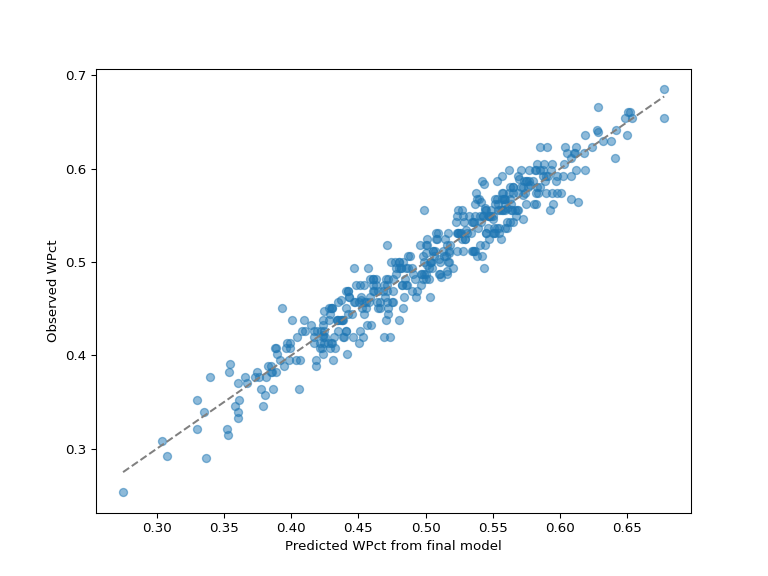

The stepwise AIC procedure selected logRS, logRA, CG, SHO, and SV. The
most important predictors are logRS and logRA, which are highly
significant and consistent with the Bill James model from Problem 2-1.
Additional pitching-related variables (CG, SHO, and SV) further improve
model fit. Compared with the model in Problem 2-1, the final model has a
substantially lower AIC (2601.364 vs. 2665.508) and residual deviance
(106.1193 vs. 180.2632), indicating a better fit while preserving the
same fundamental relationship between winning percentage and run
scoring/prevention.

## 문제 2-3

1.  `W`(승리 횟수)를 반응변수로 하여 문제 2-2의 분석을 실시하되 포아송
    회귀모형을 사용하라. 결과를 문제 2-2의 모형과 비교하라.

2.  `W`를 반응변수로 하여 문제2의 분석을 실시하되 음이항 회귀모형을
    사용하라. 모형 적합 시 오류가 발생하면 이유를 파악해서 보고하라.

### 답안

#### 2-3.1

## R

``` r
# Full Poisson model
poisson_full <- glm(
  W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO +
    CS + HBP + SF + ERA + CG + SHO + IPouts + HA + HRA +
    BBA + SOA + E + DP + FP + SV,
  data = TeamRuns_full,
  family = poisson
)

summary(poisson_full)
```


    Call:
    glm(formula = W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + 
        CS + HBP + SF + ERA + CG + SHO + IPouts + HA + HRA + BBA + 
        SOA + E + DP + FP + SV, family = poisson, data = TeamRuns_full)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -1.813e+00  1.515e+01  -0.120    0.905    
    logRS        9.409e-01  1.676e-01   5.614 1.98e-08 ***
    logRA       -1.495e-01  3.186e-01  -0.469    0.639    
    H           -1.191e-04  1.578e-04  -0.755    0.450    
    X2B         -7.447e-05  2.915e-04  -0.255    0.798    
    X3B         -3.169e-04  7.275e-04  -0.436    0.663    
    HR          -1.899e-04  3.154e-04  -0.602    0.547    
    BB          -1.157e-04  1.363e-04  -0.848    0.396    
    SO          -4.715e-05  6.375e-05  -0.740    0.460    
    CS          -4.193e-04  6.124e-04  -0.685    0.494    
    HBP          4.319e-05  3.860e-04   0.112    0.911    
    SF          -4.029e-04  7.996e-04  -0.504    0.614    
    ERA         -6.006e-02  8.039e-02  -0.747    0.455    
    CG           3.113e-03  2.571e-03   1.211    0.226    
    SHO          2.095e-03  1.802e-03   1.163    0.245    
    IPouts       1.968e-04  1.918e-04   1.026    0.305    
    HA          -1.525e-04  1.717e-04  -0.888    0.375    
    HRA         -3.460e-04  3.516e-04  -0.984    0.325    
    BBA         -8.995e-05  1.446e-04  -0.622    0.534    
    SOA          2.439e-05  6.930e-05   0.352    0.725    
    E           -1.460e-04  2.497e-03  -0.058    0.953    
    DP           2.510e-04  3.784e-04   0.663    0.507    
    FP           7.769e-01  1.517e+01   0.051    0.959    
    SV           5.802e-03  9.788e-04   5.928 3.06e-09 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for poisson family taken to be 1)

        Null deviance: 865.25  on 449  degrees of freedom
    Residual deviance:  55.73  on 426  degrees of freedom
    AIC: 2903.6

    Number of Fisher Scoring iterations: 3

``` r
# Stepwise variable selection by AIC
poisson_step <- step(
  poisson_full,
  direction = "both",
  trace = TRUE
)
```

    Start:  AIC=2903.59
    W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + CS + HBP + 
        SF + ERA + CG + SHO + IPouts + HA + HRA + BBA + SOA + E + 
        DP + FP + SV

             Df Deviance    AIC
    - FP      1   55.732 2901.6
    - E       1   55.733 2901.6
    - HBP     1   55.742 2901.6
    - X2B     1   55.795 2901.7
    - SOA     1   55.854 2901.7
    - X3B     1   55.920 2901.8
    - logRA   1   55.950 2901.8
    - SF      1   55.984 2901.8
    - HR      1   56.092 2901.9
    - BBA     1   56.117 2902.0
    - DP      1   56.170 2902.0
    - CS      1   56.199 2902.1
    - SO      1   56.277 2902.1
    - ERA     1   56.288 2902.2
    - H       1   56.300 2902.2
    - BB      1   56.450 2902.3
    - HA      1   56.519 2902.4
    - HRA     1   56.699 2902.6
    - IPouts  1   56.783 2902.6
    - SHO     1   57.082 2902.9
    - CG      1   57.193 2903.1
    <none>        55.730 2903.6
    - logRS   1   87.293 2933.2
    - SV      1   90.790 2936.7

    Step:  AIC=2901.59
    W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + CS + HBP + 
        SF + ERA + CG + SHO + IPouts + HA + HRA + BBA + SOA + E + 
        DP + SV

             Df Deviance    AIC
    - HBP     1   55.745 2899.6
    - X2B     1   55.797 2899.7
    - SOA     1   55.855 2899.7
    - X3B     1   55.920 2899.8
    - logRA   1   55.954 2899.8
    - SF      1   55.994 2899.8
    - HR      1   56.092 2899.9
    - E       1   56.103 2900.0
    - BBA     1   56.120 2900.0
    - CS      1   56.200 2900.1
    - DP      1   56.214 2900.1
    - SO      1   56.284 2900.1
    - ERA     1   56.290 2900.2
    - H       1   56.301 2900.2
    - BB      1   56.453 2900.3
    - HA      1   56.520 2900.4
    - HRA     1   56.727 2900.6
    - IPouts  1   56.949 2900.8
    - SHO     1   57.082 2900.9
    - CG      1   57.193 2901.1
    <none>        55.732 2901.6
    + FP      1   55.730 2903.6
    - logRS   1   87.429 2931.3
    - SV      1   90.794 2934.7

    Step:  AIC=2899.6
    W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + CS + SF + 
        ERA + CG + SHO + IPouts + HA + HRA + BBA + SOA + E + DP + 
        SV

             Df Deviance    AIC
    - X2B     1   55.814 2897.7
    - SOA     1   55.875 2897.7
    - X3B     1   55.950 2897.8
    - logRA   1   55.967 2897.8
    - SF      1   56.019 2897.9
    - E       1   56.109 2898.0
    - HR      1   56.135 2898.0
    - BBA     1   56.138 2898.0
    - CS      1   56.203 2898.1
    - DP      1   56.229 2898.1
    - SO      1   56.294 2898.2
    - ERA     1   56.296 2898.2
    - H       1   56.383 2898.2
    - BB      1   56.493 2898.3
    - HA      1   56.551 2898.4
    - HRA     1   56.743 2898.6
    - IPouts  1   56.981 2898.8
    - SHO     1   57.110 2899.0
    - CG      1   57.194 2899.1
    <none>        55.745 2899.6
    + HBP     1   55.732 2901.6
    + FP      1   55.742 2901.6
    - logRS   1   90.568 2932.4
    - SV      1   90.948 2932.8

    Step:  AIC=2897.67
    W ~ logRS + logRA + H + X3B + HR + BB + SO + CS + SF + ERA + 
        CG + SHO + IPouts + HA + HRA + BBA + SOA + E + DP + SV

             Df Deviance    AIC
    - SOA     1   55.936 2895.8
    - X3B     1   55.997 2895.9
    - logRA   1   56.019 2895.9
    - SF      1   56.082 2895.9
    - HR      1   56.143 2896.0
    - BBA     1   56.190 2896.1
    - E       1   56.221 2896.1
    - CS      1   56.242 2896.1
    - DP      1   56.325 2896.2
    - ERA     1   56.404 2896.3
    - SO      1   56.415 2896.3
    - BB      1   56.561 2896.4
    - H       1   56.617 2896.5
    - HA      1   56.641 2896.5
    - HRA     1   56.785 2896.6
    - IPouts  1   56.999 2896.9
    - CG      1   57.226 2897.1
    - SHO     1   57.240 2897.1
    <none>        55.814 2897.7
    + X2B     1   55.745 2899.6
    + HBP     1   55.797 2899.7
    + FP      1   55.812 2899.7
    - SV      1   91.169 2931.0
    - logRS   1   92.920 2932.8

    Step:  AIC=2895.8
    W ~ logRS + logRA + H + X3B + HR + BB + SO + CS + SF + ERA + 
        CG + SHO + IPouts + HA + HRA + BBA + E + DP + SV

             Df Deviance    AIC
    - X3B     1   56.126 2894.0
    - logRA   1   56.138 2894.0
    - SF      1   56.225 2894.1
    - HR      1   56.243 2894.1
    - BBA     1   56.296 2894.2
    - DP      1   56.347 2894.2
    - E       1   56.350 2894.2
    - SO      1   56.450 2894.3
    - CS      1   56.475 2894.3
    - ERA     1   56.530 2894.4
    - H       1   56.670 2894.5
    - BB      1   56.692 2894.6
    - HRA     1   56.819 2894.7
    - HA      1   57.064 2894.9
    - IPouts  1   57.239 2895.1
    - CG      1   57.265 2895.1
    - SHO     1   57.414 2895.3
    <none>        55.936 2895.8
    + SOA     1   55.814 2897.7
    + X2B     1   55.875 2897.7
    + HBP     1   55.910 2897.8
    + FP      1   55.934 2897.8
    - SV      1   91.528 2929.4
    - logRS   1   93.085 2930.9

    Step:  AIC=2893.99
    W ~ logRS + logRA + H + HR + BB + SO + CS + SF + ERA + CG + SHO + 
        IPouts + HA + HRA + BBA + E + DP + SV

             Df Deviance    AIC
    - logRA   1   56.278 2892.1
    - HR      1   56.314 2892.2
    - SF      1   56.452 2892.3
    - BBA     1   56.489 2892.3
    - DP      1   56.546 2892.4
    - E       1   56.601 2892.5
    - CS      1   56.793 2892.7
    - ERA     1   56.827 2892.7
    - BB      1   56.854 2892.7
    - SO      1   56.856 2892.7
    - H       1   56.949 2892.8
    - HRA     1   56.983 2892.8
    - HA      1   57.334 2893.2
    - CG      1   57.392 2893.2
    - IPouts  1   57.408 2893.3
    - SHO     1   57.593 2893.4
    <none>        56.126 2894.0
    + X3B     1   55.936 2895.8
    + SOA     1   55.997 2895.9
    + HBP     1   56.078 2895.9
    + X2B     1   56.087 2895.9
    + FP      1   56.116 2896.0
    - SV      1   91.564 2927.4
    - logRS   1   93.426 2929.3

    Step:  AIC=2892.14
    W ~ logRS + H + HR + BB + SO + CS + SF + ERA + CG + SHO + IPouts + 
        HA + HRA + BBA + E + DP + SV

             Df Deviance    AIC
    - HR      1   56.459 2890.3
    - SF      1   56.643 2890.5
    - BBA     1   56.657 2890.5
    - DP      1   56.753 2890.6
    - CS      1   56.913 2890.8
    - BB      1   57.012 2890.9
    - H       1   57.078 2890.9
    - SO      1   57.086 2890.9
    - HRA     1   57.142 2891.0
    - E       1   57.272 2891.1
    - IPouts  1   57.431 2891.3
    - HA      1   57.576 2891.4
    - CG      1   57.599 2891.5
    - SHO     1   57.897 2891.8
    <none>        56.278 2892.1
    + logRA   1   56.126 2894.0
    + X3B     1   56.138 2894.0
    + SOA     1   56.152 2894.0
    + HBP     1   56.234 2894.1
    + X2B     1   56.248 2894.1
    + FP      1   56.272 2894.1
    - ERA     1   61.062 2894.9
    - SV      1   91.868 2925.7
    - logRS   1   93.451 2927.3

    Step:  AIC=2890.32
    W ~ logRS + H + BB + SO + CS + SF + ERA + CG + SHO + IPouts + 
        HA + HRA + BBA + E + DP + SV

             Df Deviance    AIC
    - SF      1   56.735 2888.6
    - BBA     1   56.847 2888.7
    - DP      1   56.923 2888.8
    - CS      1   56.998 2888.9
    - BB      1   57.092 2888.9
    - H       1   57.104 2889.0
    - SO      1   57.439 2889.3
    - E       1   57.471 2889.3
    - HRA     1   57.502 2889.4
    - IPouts  1   57.531 2889.4
    - HA      1   57.751 2889.6
    - CG      1   57.765 2889.6
    - SHO     1   58.110 2890.0
    <none>        56.459 2890.3
    + HR      1   56.278 2892.1
    + logRA   1   56.314 2892.2
    + SOA     1   56.354 2892.2
    + HBP     1   56.396 2892.3
    + X3B     1   56.413 2892.3
    + FP      1   56.451 2892.3
    + X2B     1   56.456 2892.3
    - ERA     1   61.226 2893.1
    - SV      1   92.064 2923.9
    - logRS   1  117.451 2949.3

    Step:  AIC=2888.59
    W ~ logRS + H + BB + SO + CS + ERA + CG + SHO + IPouts + HA + 
        HRA + BBA + E + DP + SV

             Df Deviance    AIC
    - BBA     1   57.065 2886.9
    - DP      1   57.207 2887.1
    - CS      1   57.324 2887.2
    - H       1   57.372 2887.2
    - BB      1   57.462 2887.3
    - SO      1   57.521 2887.4
    - HRA     1   57.626 2887.5
    - E       1   57.718 2887.6
    - IPouts  1   57.739 2887.6
    - HA      1   57.922 2887.8
    - CG      1   58.140 2888.0
    - SHO     1   58.393 2888.2
    <none>        56.735 2888.6
    + SF      1   56.459 2890.3
    + logRA   1   56.555 2890.4
    + SOA     1   56.604 2890.5
    + HR      1   56.643 2890.5
    + HBP     1   56.650 2890.5
    + X3B     1   56.657 2890.5
    + X2B     1   56.730 2890.6
    + FP      1   56.733 2890.6
    - ERA     1   61.866 2891.7
    - SV      1   92.792 2922.7
    - logRS   1  118.003 2947.9

    Step:  AIC=2886.92
    W ~ logRS + H + BB + SO + CS + ERA + CG + SHO + IPouts + HA + 
        HRA + E + DP + SV

             Df Deviance    AIC
    - DP      1   57.393 2885.2
    - HRA     1   57.707 2885.6
    - CS      1   57.728 2885.6
    - H       1   57.783 2885.6
    - SO      1   57.807 2885.7
    - IPouts  1   57.862 2885.7
    - BB      1   57.885 2885.7
    - HA      1   57.922 2885.8
    - E       1   58.311 2886.2
    - CG      1   58.687 2886.6
    - SHO     1   58.841 2886.7
    <none>        57.065 2886.9
    + BBA     1   56.735 2888.6
    + SF      1   56.847 2888.7
    + logRA   1   56.872 2888.7
    + SOA     1   56.953 2888.8
    + HR      1   56.959 2888.8
    + HBP     1   56.972 2888.8
    + X3B     1   56.992 2888.8
    + FP      1   57.063 2888.9
    + X2B     1   57.064 2888.9
    - ERA     1   67.706 2895.6
    - SV      1   93.003 2920.9
    - logRS   1  120.272 2948.1

    Step:  AIC=2885.25
    W ~ logRS + H + BB + SO + CS + ERA + CG + SHO + IPouts + HA + 
        HRA + E + SV

             Df Deviance    AIC
    - HA      1   58.008 2883.9
    - CS      1   58.010 2883.9
    - SO      1   58.063 2883.9
    - H       1   58.075 2883.9
    - HRA     1   58.101 2884.0
    - IPouts  1   58.140 2884.0
    - BB      1   58.309 2884.2
    - E       1   58.571 2884.4
    - SHO     1   59.158 2885.0
    - CG      1   59.205 2885.1
    <none>        57.393 2885.2
    + DP      1   57.065 2886.9
    + logRA   1   57.152 2887.0
    + SF      1   57.157 2887.0
    + BBA     1   57.207 2887.1
    + HR      1   57.299 2887.2
    + HBP     1   57.302 2887.2
    + X3B     1   57.316 2887.2
    + SOA     1   57.369 2887.2
    + FP      1   57.375 2887.2
    + X2B     1   57.386 2887.2
    - ERA     1   68.419 2894.3
    - SV      1   93.275 2919.1
    - logRS   1  121.090 2946.9

    Step:  AIC=2883.87
    W ~ logRS + H + BB + SO + CS + ERA + CG + SHO + IPouts + HRA + 
        E + SV

             Df Deviance    AIC
    - HRA     1   58.367 2882.2
    - IPouts  1   58.383 2882.2
    - SO      1   58.594 2882.4
    - CS      1   58.595 2882.4
    - H       1   58.956 2882.8
    - BB      1   58.960 2882.8
    - CG      1   59.455 2883.3
    - E       1   59.594 2883.4
    <none>        58.008 2883.9
    - SHO     1   60.032 2883.9
    + HA      1   57.393 2885.2
    + logRA   1   57.723 2885.6
    + SOA     1   57.770 2885.6
    + SF      1   57.823 2885.7
    + HBP     1   57.855 2885.7
    + X3B     1   57.899 2885.8
    + HR      1   57.911 2885.8
    + DP      1   57.922 2885.8
    + X2B     1   57.997 2885.9
    + FP      1   58.006 2885.9
    + BBA     1   58.007 2885.9
    - ERA     1   93.290 2917.2
    - SV      1   93.295 2917.2
    - logRS   1  126.628 2950.5

    Step:  AIC=2882.23
    W ~ logRS + H + BB + SO + CS + ERA + CG + SHO + IPouts + E + 
        SV

             Df Deviance    AIC
    - IPouts  1   58.710 2880.6
    - CS      1   58.885 2880.7
    - SO      1   59.025 2880.9
    - H       1   59.102 2881.0
    - BB      1   59.274 2881.1
    - E       1   59.770 2881.6
    - CG      1   59.865 2881.7
    <none>        58.367 2882.2
    - SHO     1   60.422 2882.3
    + HRA     1   58.008 2883.9
    + HA      1   58.101 2884.0
    + logRA   1   58.105 2884.0
    + HR      1   58.177 2884.0
    + DP      1   58.207 2884.1
    + HBP     1   58.243 2884.1
    + SF      1   58.248 2884.1
    + SOA     1   58.306 2884.2
    + X3B     1   58.311 2884.2
    + FP      1   58.355 2884.2
    + BBA     1   58.359 2884.2
    + X2B     1   58.365 2884.2
    - SV      1   93.446 2915.3
    - ERA     1  119.003 2940.9
    - logRS   1  131.957 2953.8

    Step:  AIC=2880.57
    W ~ logRS + H + BB + SO + CS + ERA + CG + SHO + E + SV

             Df Deviance    AIC
    - CS      1   59.120 2879.0
    - H       1   59.173 2879.0
    - SO      1   59.212 2879.1
    - BB      1   59.417 2879.3
    - E       1   60.110 2880.0
    - CG      1   60.250 2880.1
    - SHO     1   60.670 2880.5
    <none>        58.710 2880.6
    + IPouts  1   58.367 2882.2
    + HRA     1   58.383 2882.2
    + DP      1   58.518 2882.4
    + HR      1   58.575 2882.4
    + HBP     1   58.583 2882.4
    + SF      1   58.598 2882.5
    + logRA   1   58.598 2882.5
    + FP      1   58.618 2882.5
    + HA      1   58.630 2882.5
    + X3B     1   58.648 2882.5
    + SOA     1   58.652 2882.5
    + BBA     1   58.702 2882.6
    + X2B     1   58.710 2882.6
    - SV      1   95.587 2915.4
    - ERA     1  131.823 2951.7
    - logRS   1  134.605 2954.5

    Step:  AIC=2878.98
    W ~ logRS + H + BB + SO + ERA + CG + SHO + E + SV

             Df Deviance    AIC
    - SO      1   59.545 2877.4
    - H       1   59.630 2877.5
    - BB      1   59.853 2877.7
    - CG      1   60.554 2878.4
    - E       1   60.758 2878.6
    <none>        59.120 2879.0
    - SHO     1   61.159 2879.0
    + CS      1   58.710 2880.6
    + HRA     1   58.848 2880.7
    + IPouts  1   58.885 2880.7
    + DP      1   58.965 2880.8
    + X3B     1   58.969 2880.8
    + SF      1   58.978 2880.8
    + SOA     1   58.984 2880.8
    + logRA   1   59.010 2880.9
    + HBP     1   59.018 2880.9
    + HA      1   59.018 2880.9
    + HR      1   59.059 2880.9
    + FP      1   59.079 2880.9
    + X2B     1   59.118 2881.0
    + BBA     1   59.120 2881.0
    - SV      1   95.619 2913.5
    - ERA     1  132.780 2950.6
    - logRS   1  138.417 2956.3

    Step:  AIC=2877.4
    W ~ logRS + H + BB + ERA + CG + SHO + E + SV

             Df Deviance    AIC
    - H       1   59.727 2875.6
    - BB      1   60.353 2876.2
    - E       1   61.436 2877.3
    <none>        59.545 2877.4
    - SHO     1   61.548 2877.4
    - CG      1   61.722 2877.6
    + SO      1   59.120 2879.0
    + HRA     1   59.211 2879.1
    + CS      1   59.212 2879.1
    + X3B     1   59.340 2879.2
    + HR      1   59.368 2879.2
    + logRA   1   59.378 2879.2
    + DP      1   59.413 2879.3
    + IPouts  1   59.418 2879.3
    + HBP     1   59.444 2879.3
    + HA      1   59.452 2879.3
    + FP      1   59.507 2879.4
    + SF      1   59.507 2879.4
    + SOA     1   59.509 2879.4
    + BBA     1   59.544 2879.4
    + X2B     1   59.545 2879.4
    - SV      1   95.857 2911.7
    - ERA     1  137.620 2953.5
    - logRS   1  142.602 2958.5

    Step:  AIC=2875.59
    W ~ logRS + BB + ERA + CG + SHO + E + SV

             Df Deviance    AIC
    - BB      1   60.353 2874.2
    <none>        59.727 2875.6
    - CG      1   61.757 2875.6
    - SHO     1   61.803 2875.7
    - E       1   61.865 2875.7
    + CS      1   59.337 2877.2
    + X3B     1   59.427 2877.3
    + HA      1   59.512 2877.4
    + HBP     1   59.528 2877.4
    + H       1   59.545 2877.4
    + logRA   1   59.546 2877.4
    + HRA     1   59.564 2877.4
    + SO      1   59.630 2877.5
    + SOA     1   59.641 2877.5
    + DP      1   59.650 2877.5
    + SF      1   59.655 2877.5
    + X2B     1   59.694 2877.6
    + IPouts  1   59.696 2877.6
    + HR      1   59.705 2877.6
    + FP      1   59.725 2877.6
    + BBA     1   59.727 2877.6
    - SV      1   95.860 2909.7
    - ERA     1  137.659 2951.5
    - logRS   1  229.061 3042.9

    Step:  AIC=2874.21
    W ~ logRS + ERA + CG + SHO + E + SV

             Df Deviance    AIC
    - SHO     1   62.294 2874.2
    <none>        60.353 2874.2
    - E       1   62.490 2874.3
    - CG      1   62.505 2874.4
    + BB      1   59.727 2875.6
    + CS      1   60.009 2875.9
    + SO      1   60.035 2875.9
    + HRA     1   60.082 2875.9
    + logRA   1   60.104 2876.0
    + X3B     1   60.132 2876.0
    + DP      1   60.198 2876.1
    + HBP     1   60.211 2876.1
    + HA      1   60.227 2876.1
    + SF      1   60.283 2876.1
    + HR      1   60.292 2876.2
    + SOA     1   60.315 2876.2
    + IPouts  1   60.336 2876.2
    + X2B     1   60.351 2876.2
    + FP      1   60.351 2876.2
    + BBA     1   60.353 2876.2
    + H       1   60.353 2876.2
    - SV      1   98.334 2910.2
    - ERA     1  139.211 2951.1
    - logRS   1  302.688 3114.6

    Step:  AIC=2874.15
    W ~ logRS + ERA + CG + E + SV

             Df Deviance    AIC
    <none>        62.294 2874.2
    + SHO     1   60.353 2874.2
    - CG      1   64.949 2874.8
    - E       1   65.189 2875.1
    + BB      1   61.803 2875.7
    + logRA   1   61.818 2875.7
    + CS      1   61.860 2875.7
    + HA      1   62.003 2875.9
    + HRA     1   62.043 2875.9
    + HBP     1   62.047 2875.9
    + SO      1   62.072 2875.9
    + X3B     1   62.081 2875.9
    + SOA     1   62.173 2876.0
    + DP      1   62.201 2876.1
    + SF      1   62.219 2876.1
    + HR      1   62.242 2876.1
    + X2B     1   62.266 2876.1
    + H       1   62.285 2876.1
    + FP      1   62.287 2876.2
    + BBA     1   62.294 2876.2
    + IPouts  1   62.294 2876.2
    - SV      1   99.901 2909.8
    - ERA     1  192.694 3002.6
    - logRS   1  306.144 3116.0

``` r
summary(poisson_step)
```


    Call:
    glm(formula = W ~ logRS + ERA + CG + E + SV, family = poisson, 
        data = TeamRuns_full)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -0.3757640  0.3476706  -1.081    0.280    
    logRS        0.7921194  0.0507212  15.617  < 2e-16 ***
    ERA         -0.1534248  0.0134578 -11.400  < 2e-16 ***
    CG           0.0033842  0.0020730   1.633    0.103    
    E           -0.0006008  0.0003532  -1.701    0.089 .  
    SV           0.0056969  0.0009280   6.139 8.29e-10 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for poisson family taken to be 1)

        Null deviance: 865.249  on 449  degrees of freedom
    Residual deviance:  62.294  on 444  degrees of freedom
    AIC: 2874.2

    Number of Fisher Scoring iterations: 3

``` r
# Check whether remaining variables should be kept
drop1(
  poisson_step,
  test = "Chisq"
)
```

    Single term deletions

    Model:
    W ~ logRS + ERA + CG + E + SV
           Df Deviance    AIC     LRT  Pr(>Chi)    
    <none>      62.294 2874.2                      
    logRS   1  306.144 3116.0 243.850 < 2.2e-16 ***
    ERA     1  192.694 3002.6 130.399 < 2.2e-16 ***
    CG      1   64.949 2874.8   2.655   0.10325    
    E       1   65.189 2875.1   2.894   0.08889 .  
    SV      1   99.901 2909.8  37.606 8.657e-10 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

``` r
# Final Poisson model
poisson_final <- poisson_step

summary(poisson_final)
```


    Call:
    glm(formula = W ~ logRS + ERA + CG + E + SV, family = poisson, 
        data = TeamRuns_full)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -0.3757640  0.3476706  -1.081    0.280    
    logRS        0.7921194  0.0507212  15.617  < 2e-16 ***
    ERA         -0.1534248  0.0134578 -11.400  < 2e-16 ***
    CG           0.0033842  0.0020730   1.633    0.103    
    E           -0.0006008  0.0003532  -1.701    0.089 .  
    SV           0.0056969  0.0009280   6.139 8.29e-10 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for poisson family taken to be 1)

        Null deviance: 865.249  on 449  degrees of freedom
    Residual deviance:  62.294  on 444  degrees of freedom
    AIC: 2874.2

    Number of Fisher Scoring iterations: 3

``` r
confint(poisson_final)
```

                        2.5 %        97.5 %
    (Intercept) -1.0573308225  3.055120e-01
    logRS        0.6927068693  8.915305e-01
    ERA         -0.1798090277 -1.270554e-01
    CG          -0.0006885303  7.437531e-03
    E           -0.0012933844  9.131542e-05
    SV           0.0038774841  7.514994e-03

``` r
# Selected variables
names(coef(poisson_final))
```

    [1] "(Intercept)" "logRS"       "ERA"         "CG"          "E"          
    [6] "SV"         

``` r
# Compare with 2-2 final logistic model
model_compare_23 <- data.frame(
  model = c(
    "2-2 logistic stepwise model",
    "2-3 Poisson stepwise model"
  ),
  AIC = c(
    AIC(final_fit),
    AIC(poisson_final)
  ),
  residual_deviance = c(
    deviance(final_fit),
    deviance(poisson_final)
  ),
  residual_df = c(
    df.residual(final_fit),
    df.residual(poisson_final)
  )
)

model_compare_23
```

                            model      AIC residual_deviance residual_df
    1 2-2 logistic stepwise model 2601.364         106.11932         444
    2  2-3 Poisson stepwise model 2874.154          62.29446         444

## Python

``` python
# Full Poisson model
predictors = [
    "logRS", "logRA", "H", "X2B", "X3B", "HR", "BB", "SO",
    "CS", "HBP", "SF", "ERA", "CG", "SHO", "IPouts", "HA",
    "HRA", "BBA", "SOA", "E", "DP", "FP", "SV"
]

X_full = sm.add_constant(df_full[predictors])
y_poisson = df_full["W"]

poisson_full = sm.GLM(
    y_poisson,
    X_full,
    family=sm.families.Poisson()
).fit()

print(poisson_full.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:                      W   No. Observations:                  420
    Model:                            GLM   Df Residuals:                      396
    Model Family:                 Poisson   Df Model:                           23
    Link Function:                    Log   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1332.4
    Date:                Fri, 12 Jun 2026   Deviance:                       51.548
    Time:                        05:23:40   Pearson chi2:                     51.3
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.8366
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         -1.2187     15.921     -0.077      0.939     -32.424      29.986
    logRS          0.9339      0.173      5.392      0.000       0.594       1.273
    logRA         -0.1514      0.329     -0.461      0.645      -0.796       0.493
    H             -0.0001      0.000     -0.691      0.490      -0.000       0.000
    X2B         -5.93e-05      0.000     -0.195      0.845      -0.001       0.001
    X3B           -0.0002      0.001     -0.304      0.761      -0.002       0.001
    HR            -0.0002      0.000     -0.543      0.587      -0.001       0.000
    BB            -0.0001      0.000     -0.777      0.437      -0.000       0.000
    SO          -4.33e-05   6.55e-05     -0.661      0.508      -0.000     8.5e-05
    CS            -0.0004      0.001     -0.695      0.487      -0.002       0.001
    HBP         2.824e-05      0.000      0.070      0.944      -0.001       0.001
    SF            -0.0004      0.001     -0.482      0.630      -0.002       0.001
    ERA           -0.0656      0.084     -0.784      0.433      -0.230       0.099
    CG             0.0030      0.003      1.125      0.260      -0.002       0.008
    SHO            0.0019      0.002      1.038      0.299      -0.002       0.006
    IPouts         0.0002      0.000      0.885      0.376      -0.000       0.001
    HA            -0.0001      0.000     -0.829      0.407      -0.000       0.000
    HRA           -0.0003      0.000     -0.954      0.340      -0.001       0.000
    BBA        -8.681e-05      0.000     -0.581      0.561      -0.000       0.000
    SOA         2.295e-05   7.11e-05      0.323      0.747      -0.000       0.000
    E             -0.0002      0.003     -0.086      0.931      -0.005       0.005
    DP             0.0003      0.000      0.806      0.420      -0.000       0.001
    FP             0.3297     15.915      0.021      0.983     -30.864      31.523
    SV             0.0057      0.001      5.661      0.000       0.004       0.008
    ==============================================================================

``` python
# Stepwise variable selection by AIC
exec("""
def fit_poisson(selected_vars):
    X = sm.add_constant(df_full[selected_vars])
    model = sm.GLM(
        y_poisson,
        X,
        family=sm.families.Poisson()
    ).fit()
    return model

def stepwise_aic_poisson(all_vars):
    selected = all_vars.copy()
    current_model = fit_poisson(selected)
    current_aic = current_model.aic

    changed = True

    while changed:
        changed = False
        candidates = []

        for var in selected:
            trial_vars = [v for v in selected if v != var]
            trial_model = fit_poisson(trial_vars)
            candidates.append({
                "action": "remove",
                "var": var,
                "vars": trial_vars,
                "aic": trial_model.aic,
                "model": trial_model
            })

        remaining = [v for v in all_vars if v not in selected]

        for var in remaining:
            trial_vars = selected + [var]
            trial_model = fit_poisson(trial_vars)
            candidates.append({
                "action": "add",
                "var": var,
                "vars": trial_vars,
                "aic": trial_model.aic,
                "model": trial_model
            })

        best = min(candidates, key=lambda x: x["aic"])

        if best["aic"] < current_aic:
            selected = best["vars"]
            current_model = best["model"]
            current_aic = best["aic"]
            changed = True
            print(f"{best['action']} {best['var']}: AIC = {current_aic:.4f}")

    return current_model, selected
""")

poisson_step, selected_poisson_vars = stepwise_aic_poisson(predictors)
```

    remove FP: AIC = 2710.7339
    remove HBP: AIC = 2708.7388
    remove X2B: AIC = 2706.7792
    remove X3B: AIC = 2704.8667
    remove SOA: AIC = 2702.9766
    remove logRA: AIC = 2701.1436
    remove HR: AIC = 2699.3206
    remove SF: AIC = 2697.5403
    remove BBA: AIC = 2695.8259
    remove DP: AIC = 2694.3578
    remove HA: AIC = 2692.7887
    remove IPouts: AIC = 2691.0209
    remove SO: AIC = 2689.3500
    remove H: AIC = 2687.6037
    remove HRA: AIC = 2685.9345
    remove CS: AIC = 2684.3246
    remove BB: AIC = 2682.9585
    remove SHO: AIC = 2682.5096

``` python
print(poisson_step.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:                      W   No. Observations:                  420
    Model:                            GLM   Df Residuals:                      414
    Model Family:                 Poisson   Df Model:                            5
    Link Function:                    Log   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1335.3
    Date:                Fri, 12 Jun 2026   Deviance:                       57.324
    Time:                        05:23:42   Pearson chi2:                     57.0
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.8344
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         -0.3811      0.357     -1.066      0.286      -1.081       0.319
    logRS          0.7954      0.052     15.312      0.000       0.694       0.897
    ERA           -0.1561      0.014    -11.236      0.000      -0.183      -0.129
    CG             0.0033      0.002      1.560      0.119      -0.001       0.007
    E             -0.0006      0.000     -1.582      0.114      -0.001       0.000
    SV             0.0055      0.001      5.827      0.000       0.004       0.007
    ==============================================================================

``` python
# Check whether remaining variables should be kept
drop1_results = []

for var in selected_poisson_vars:
    reduced_vars = [v for v in selected_poisson_vars if v != var]
    reduced_fit = fit_poisson(reduced_vars)

    lrt = reduced_fit.deviance - poisson_step.deviance
    pval = 1 - chi2.cdf(lrt, df=1)

    drop1_results.append({
        "variable": var,
        "reduced_deviance": reduced_fit.deviance,
        "reduced_AIC": reduced_fit.aic,
        "LRT": lrt,
        "p_value": pval
    })

drop1_table = pd.DataFrame(drop1_results)
print(drop1_table)
```

      variable  reduced_deviance  reduced_AIC         LRT       p_value
    0    logRS        291.748201  2914.933391  234.423834  0.000000e+00
    1      ERA        183.837130  2807.022320  126.512764  0.000000e+00
    2       CG         59.749705  2682.934895    2.425339  1.193874e-01
    3        E         59.829601  2683.014791    2.505235  1.134686e-01
    4       SV         91.194667  2714.379857   33.870300  5.891117e-09

``` python
# Final Poisson model
poisson_final = poisson_step

print(poisson_final.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:                      W   No. Observations:                  420
    Model:                            GLM   Df Residuals:                      414
    Model Family:                 Poisson   Df Model:                            5
    Link Function:                    Log   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1335.3
    Date:                Fri, 12 Jun 2026   Deviance:                       57.324
    Time:                        05:23:42   Pearson chi2:                     57.0
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.8344
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         -0.3811      0.357     -1.066      0.286      -1.081       0.319
    logRS          0.7954      0.052     15.312      0.000       0.694       0.897
    ERA           -0.1561      0.014    -11.236      0.000      -0.183      -0.129
    CG             0.0033      0.002      1.560      0.119      -0.001       0.007
    E             -0.0006      0.000     -1.582      0.114      -0.001       0.000
    SV             0.0055      0.001      5.827      0.000       0.004       0.007
    ==============================================================================

``` python
print(poisson_final.conf_int())
```

                  0         1
    const -1.081480  0.319365
    logRS  0.693548  0.897158
    ERA   -0.183369 -0.128898
    CG    -0.000846  0.007454
    E     -0.001317  0.000140
    SV     0.003680  0.007410

``` python
# Selected variables
print(["const"] + selected_poisson_vars)
```

    ['const', 'logRS', 'ERA', 'CG', 'E', 'SV']

``` python
# Compare with 2-2 final logistic model
model_compare_23 = pd.DataFrame({
    "model": [
        "2-2 logistic stepwise model",
        "2-3 Poisson stepwise model"
    ],
    "AIC": [
        final_fit.aic,
        poisson_final.aic
    ],
    "residual_deviance": [
        final_fit.deviance,
        poisson_final.deviance
    ],
    "residual_df": [
        final_fit.df_resid,
        poisson_final.df_resid
    ]
})

print(model_compare_23)
```

                             model          AIC  residual_deviance  residual_df
    0  2-2 logistic stepwise model  2428.540898          98.927724          414
    1   2-3 Poisson stepwise model  2682.509557          57.324367          414

Stepwise AIC selected logRS, ERA, CG, E, and SV. Among these variables,
logRS, ERA, and SV are highly significant (p\<0.001), while CG and E are
not significant at the 5% level. However, removing either variable
slightly increases the AIC, so both were retained in the final model.

Compared with Question 2-2, the logistic model selected logRS, logRA,
CG, SHO, and SV, whereas the Poisson model selected logRS, ERA, CG, E,
and SV. Both models identify logRS, CG, and SV as important predictors,
indicating that offensive production and pitching performance are
strongly associated with team success.

#### 2-3.2

## R

``` r
# Full negative binomial model
nb_full <- glm.nb(
  W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO +
    CS + HBP + SF + ERA + CG + SHO + IPouts + HA + HRA +
    BBA + SOA + E + DP + FP + SV,
  data = TeamRuns_full
)

summary(nb_full)
```


    Call:
    glm.nb(formula = W ~ logRS + logRA + H + X2B + X3B + HR + BB + 
        SO + CS + HBP + SF + ERA + CG + SHO + IPouts + HA + HRA + 
        BBA + SOA + E + DP + FP + SV, data = TeamRuns_full, init.theta = 10848330.35, 
        link = log)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -1.813e+00  1.515e+01  -0.120    0.905    
    logRS        9.409e-01  1.676e-01   5.614 1.98e-08 ***
    logRA       -1.495e-01  3.186e-01  -0.469    0.639    
    H           -1.191e-04  1.578e-04  -0.755    0.450    
    X2B         -7.447e-05  2.915e-04  -0.255    0.798    
    X3B         -3.169e-04  7.275e-04  -0.436    0.663    
    HR          -1.899e-04  3.154e-04  -0.602    0.547    
    BB          -1.157e-04  1.363e-04  -0.848    0.396    
    SO          -4.715e-05  6.375e-05  -0.740    0.460    
    CS          -4.193e-04  6.124e-04  -0.685    0.494    
    HBP          4.319e-05  3.860e-04   0.112    0.911    
    SF          -4.029e-04  7.996e-04  -0.504    0.614    
    ERA         -6.006e-02  8.039e-02  -0.747    0.455    
    CG           3.113e-03  2.571e-03   1.211    0.226    
    SHO          2.095e-03  1.802e-03   1.163    0.245    
    IPouts       1.968e-04  1.918e-04   1.026    0.305    
    HA          -1.525e-04  1.717e-04  -0.888    0.375    
    HRA         -3.460e-04  3.516e-04  -0.984    0.325    
    BBA         -8.995e-05  1.446e-04  -0.622    0.534    
    SOA          2.439e-05  6.930e-05   0.352    0.725    
    E           -1.460e-04  2.497e-03  -0.058    0.953    
    DP           2.510e-04  3.784e-04   0.663    0.507    
    FP           7.769e-01  1.517e+01   0.051    0.959    
    SV           5.802e-03  9.788e-04   5.928 3.06e-09 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for Negative Binomial(10849178) family taken to be 1)

        Null deviance: 865.243  on 449  degrees of freedom
    Residual deviance:  55.729  on 426  degrees of freedom
    AIC: 2905.6

    Number of Fisher Scoring iterations: 1

                  Theta:  10848330 
              Std. Err.:  108586594 
    Warning while fitting theta: alternation limit reached 

     2 x log-likelihood:  -2855.592 

``` r
# Stepwise variable selection by AIC
nb_step <- step(
  nb_full,
  direction = "both",
  trace = TRUE
)
```

    Start:  AIC=2903.59
    W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + CS + HBP + 
        SF + ERA + CG + SHO + IPouts + HA + HRA + BBA + SOA + E + 
        DP + FP + SV

             Df Deviance    AIC
    - FP      1   55.732 2901.6
    - E       1   55.733 2901.6
    - HBP     1   55.742 2901.6
    - X2B     1   55.795 2901.7
    - SOA     1   55.853 2901.7
    - X3B     1   55.919 2901.8
    - logRA   1   55.950 2901.8
    - SF      1   55.983 2901.8
    - HR      1   56.092 2901.9
    - BBA     1   56.117 2902.0
    - DP      1   56.169 2902.0
    - CS      1   56.198 2902.1
    - SO      1   56.276 2902.1
    - ERA     1   56.288 2902.2
    - H       1   56.300 2902.2
    - BB      1   56.450 2902.3
    - HA      1   56.518 2902.4
    - HRA     1   56.698 2902.6
    - IPouts  1   56.782 2902.7
    - SHO     1   57.082 2902.9
    - CG      1   57.193 2903.1
    <none>        55.729 2903.6
    - logRS   1   87.292 2933.2
    - SV      1   90.790 2936.7


    Step:  AIC=2901.59
    W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + CS + HBP + 
        SF + ERA + CG + SHO + IPouts + HA + HRA + BBA + SOA + E + 
        DP + SV

             Df Deviance    AIC
    - HBP     1   55.744 2899.6
    - X2B     1   55.797 2899.7
    - SOA     1   55.854 2899.7
    - X3B     1   55.919 2899.8
    - logRA   1   55.954 2899.8
    - SF      1   55.993 2899.9
    - HR      1   56.092 2899.9
    - E       1   56.103 2900.0
    - BBA     1   56.120 2900.0
    - CS      1   56.200 2900.1
    - DP      1   56.213 2900.1
    - SO      1   56.283 2900.2
    - ERA     1   56.289 2900.2
    - H       1   56.301 2900.2
    - BB      1   56.452 2900.3
    - HA      1   56.520 2900.4
    - HRA     1   56.727 2900.6
    - IPouts  1   56.948 2900.8
    - SHO     1   57.082 2900.9
    - CG      1   57.193 2901.1
    <none>        55.732 2901.6
    + FP      1   55.729 2903.6
    - logRS   1   87.429 2931.3
    - SV      1   90.794 2934.7


    Step:  AIC=2899.61
    W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + CS + SF + 
        ERA + CG + SHO + IPouts + HA + HRA + BBA + SOA + E + DP + 
        SV

             Df Deviance    AIC
    - X2B     1   55.814 2897.7
    - SOA     1   55.875 2897.7
    - X3B     1   55.950 2897.8
    - logRA   1   55.967 2897.8
    - SF      1   56.018 2897.9
    - E       1   56.109 2898.0
    - HR      1   56.135 2898.0
    - BBA     1   56.138 2898.0
    - CS      1   56.203 2898.1
    - DP      1   56.229 2898.1
    - SO      1   56.294 2898.2
    - ERA     1   56.296 2898.2
    - H       1   56.382 2898.2
    - BB      1   56.493 2898.4
    - HA      1   56.550 2898.4
    - HRA     1   56.742 2898.6
    - IPouts  1   56.981 2898.8
    - SHO     1   57.110 2899.0
    - CG      1   57.193 2899.1
    <none>        55.744 2899.6
    + HBP     1   55.732 2901.6
    + FP      1   55.742 2901.6
    - logRS   1   90.567 2932.4
    - SV      1   90.947 2932.8


    Step:  AIC=2897.68
    W ~ logRS + logRA + H + X3B + HR + BB + SO + CS + SF + ERA + 
        CG + SHO + IPouts + HA + HRA + BBA + SOA + E + DP + SV

             Df Deviance    AIC
    - SOA     1   55.935 2895.8
    - X3B     1   55.997 2895.9
    - logRA   1   56.019 2895.9
    - SF      1   56.081 2895.9
    - HR      1   56.143 2896.0
    - BBA     1   56.189 2896.1
    - E       1   56.221 2896.1
    - CS      1   56.241 2896.1
    - DP      1   56.324 2896.2
    - ERA     1   56.404 2896.3
    - SO      1   56.415 2896.3
    - BB      1   56.561 2896.4
    - H       1   56.617 2896.5
    - HA      1   56.641 2896.5
    - HRA     1   56.784 2896.7
    - IPouts  1   56.999 2896.9
    - CG      1   57.225 2897.1
    - SHO     1   57.239 2897.1
    <none>        55.814 2897.7
    + X2B     1   55.744 2899.6
    + HBP     1   55.797 2899.7
    + FP      1   55.812 2899.7
    - SV      1   91.168 2931.0
    - logRS   1   92.919 2932.8


    Step:  AIC=2895.8
    W ~ logRS + logRA + H + X3B + HR + BB + SO + CS + SF + ERA + 
        CG + SHO + IPouts + HA + HRA + BBA + E + DP + SV

             Df Deviance    AIC
    - X3B     1   56.126 2894.0
    - logRA   1   56.137 2894.0
    - SF      1   56.224 2894.1
    - HR      1   56.242 2894.1
    - BBA     1   56.295 2894.2
    - DP      1   56.346 2894.2
    - E       1   56.350 2894.2
    - SO      1   56.450 2894.3
    - CS      1   56.475 2894.3
    - ERA     1   56.530 2894.4
    - H       1   56.670 2894.5
    - BB      1   56.692 2894.6
    - HRA     1   56.818 2894.7
    - HA      1   57.064 2894.9
    - IPouts  1   57.239 2895.1
    - CG      1   57.264 2895.1
    - SHO     1   57.414 2895.3
    <none>        55.935 2895.8
    + SOA     1   55.814 2897.7
    + X2B     1   55.875 2897.7
    + HBP     1   55.909 2897.8
    + FP      1   55.934 2897.8
    - SV      1   91.528 2929.4
    - logRS   1   93.084 2930.9


    Step:  AIC=2893.99
    W ~ logRS + logRA + H + HR + BB + SO + CS + SF + ERA + CG + SHO + 
        IPouts + HA + HRA + BBA + E + DP + SV

             Df Deviance    AIC
    - logRA   1   56.277 2892.1
    - HR      1   56.313 2892.2
    - SF      1   56.452 2892.3
    - BBA     1   56.489 2892.3
    - DP      1   56.546 2892.4
    - E       1   56.601 2892.5
    - CS      1   56.792 2892.7
    - ERA     1   56.827 2892.7
    - BB      1   56.853 2892.7
    - SO      1   56.855 2892.7
    - H       1   56.949 2892.8
    - HRA     1   56.983 2892.8
    - HA      1   57.333 2893.2
    - CG      1   57.392 2893.2
    - IPouts  1   57.408 2893.3
    - SHO     1   57.593 2893.5
    <none>        56.126 2894.0
    + X3B     1   55.935 2895.8
    + SOA     1   55.997 2895.9
    + HBP     1   56.078 2895.9
    + X2B     1   56.086 2895.9
    + FP      1   56.116 2896.0
    - SV      1   91.564 2927.4
    - logRS   1   93.426 2929.3


    Step:  AIC=2892.14
    W ~ logRS + H + HR + BB + SO + CS + SF + ERA + CG + SHO + IPouts + 
        HA + HRA + BBA + E + DP + SV

             Df Deviance    AIC
    - HR      1   56.458 2890.3
    - SF      1   56.642 2890.5
    - BBA     1   56.657 2890.5
    - DP      1   56.752 2890.6
    - CS      1   56.912 2890.8
    - BB      1   57.012 2890.9
    - H       1   57.078 2890.9
    - SO      1   57.085 2890.9
    - HRA     1   57.142 2891.0
    - E       1   57.272 2891.1
    - IPouts  1   57.431 2891.3
    - HA      1   57.576 2891.4
    - CG      1   57.598 2891.5
    - SHO     1   57.896 2891.8
    <none>        56.277 2892.1
    + logRA   1   56.126 2894.0
    + X3B     1   56.137 2894.0
    + SOA     1   56.152 2894.0
    + HBP     1   56.233 2894.1
    + X2B     1   56.247 2894.1
    + FP      1   56.271 2894.1
    - ERA     1   61.061 2894.9
    - SV      1   91.867 2925.7
    - logRS   1   93.451 2927.3


    Step:  AIC=2890.32
    W ~ logRS + H + BB + SO + CS + SF + ERA + CG + SHO + IPouts + 
        HA + HRA + BBA + E + DP + SV

             Df Deviance    AIC
    - SF      1   56.734 2888.6
    - BBA     1   56.847 2888.7
    - DP      1   56.922 2888.8
    - CS      1   56.998 2888.9
    - BB      1   57.091 2888.9
    - H       1   57.104 2889.0
    - SO      1   57.439 2889.3
    - E       1   57.471 2889.3
    - HRA     1   57.501 2889.4
    - IPouts  1   57.531 2889.4
    - HA      1   57.750 2889.6
    - CG      1   57.764 2889.6
    - SHO     1   58.109 2890.0
    <none>        56.458 2890.3
    + HR      1   56.277 2892.1
    + logRA   1   56.313 2892.2
    + SOA     1   56.354 2892.2
    + HBP     1   56.396 2892.3
    + X3B     1   56.413 2892.3
    + FP      1   56.451 2892.3
    + X2B     1   56.455 2892.3
    - ERA     1   61.225 2893.1
    - SV      1   92.064 2923.9
    - logRS   1  117.451 2949.3


    Step:  AIC=2888.6
    W ~ logRS + H + BB + SO + CS + ERA + CG + SHO + IPouts + HA + 
        HRA + BBA + E + DP + SV

             Df Deviance    AIC
    - BBA     1   57.064 2886.9
    - DP      1   57.207 2887.1
    - CS      1   57.324 2887.2
    - H       1   57.372 2887.2
    - BB      1   57.462 2887.3
    - SO      1   57.520 2887.4
    - HRA     1   57.625 2887.5
    - E       1   57.717 2887.6
    - IPouts  1   57.738 2887.6
    - HA      1   57.921 2887.8
    - CG      1   58.140 2888.0
    - SHO     1   58.393 2888.3
    <none>        56.734 2888.6
    + SF      1   56.458 2890.3
    + logRA   1   56.554 2890.4
    + SOA     1   56.604 2890.5
    + HR      1   56.642 2890.5
    + HBP     1   56.649 2890.5
    + X3B     1   56.656 2890.5
    + X2B     1   56.730 2890.6
    + FP      1   56.732 2890.6
    - ERA     1   61.865 2891.7
    - SV      1   92.792 2922.7
    - logRS   1  118.002 2947.9


    Step:  AIC=2886.93
    W ~ logRS + H + BB + SO + CS + ERA + CG + SHO + IPouts + HA + 
        HRA + E + DP + SV

             Df Deviance    AIC
    - DP      1   57.393 2885.3
    - HRA     1   57.707 2885.6
    - CS      1   57.727 2885.6
    - H       1   57.783 2885.7
    - SO      1   57.806 2885.7
    - IPouts  1   57.862 2885.7
    - BB      1   57.884 2885.8
    - HA      1   57.921 2885.8
    - E       1   58.311 2886.2
    - CG      1   58.687 2886.6
    - SHO     1   58.840 2886.7
    <none>        57.064 2886.9
    + BBA     1   56.734 2888.6
    + SF      1   56.847 2888.7
    + logRA   1   56.872 2888.7
    + SOA     1   56.953 2888.8
    + HR      1   56.959 2888.8
    + HBP     1   56.971 2888.8
    + X3B     1   56.992 2888.8
    + FP      1   57.063 2888.9
    + X2B     1   57.064 2888.9
    - ERA     1   67.706 2895.6
    - SV      1   93.003 2920.9
    - logRS   1  120.271 2948.1


    Step:  AIC=2885.26
    W ~ logRS + H + BB + SO + CS + ERA + CG + SHO + IPouts + HA + 
        HRA + E + SV

             Df Deviance    AIC
    - HA      1   58.007 2883.9
    - CS      1   58.009 2883.9
    - SO      1   58.063 2883.9
    - H       1   58.074 2883.9
    - HRA     1   58.101 2884.0
    - IPouts  1   58.140 2884.0
    - BB      1   58.309 2884.2
    - E       1   58.571 2884.4
    - SHO     1   59.157 2885.0
    - CG      1   59.204 2885.1
    <none>        57.393 2885.3
    + DP      1   57.064 2886.9
    + logRA   1   57.152 2887.0
    + SF      1   57.156 2887.0
    + BBA     1   57.207 2887.1
    + HR      1   57.298 2887.2
    + HBP     1   57.302 2887.2
    + X3B     1   57.316 2887.2
    + SOA     1   57.368 2887.2
    + FP      1   57.375 2887.2
    + X2B     1   57.386 2887.2
    - ERA     1   68.418 2894.3
    - SV      1   93.274 2919.1
    - logRS   1  121.089 2946.9


    Step:  AIC=2883.87
    W ~ logRS + H + BB + SO + CS + ERA + CG + SHO + IPouts + HRA + 
        E + SV

             Df Deviance    AIC
    - HRA     1   58.367 2882.2
    - IPouts  1   58.383 2882.2
    - SO      1   58.594 2882.5
    - CS      1   58.594 2882.5
    - H       1   58.955 2882.8
    - BB      1   58.960 2882.8
    - CG      1   59.455 2883.3
    - E       1   59.593 2883.5
    <none>        58.007 2883.9
    - SHO     1   60.032 2883.9
    + HA      1   57.393 2885.3
    + logRA   1   57.723 2885.6
    + SOA     1   57.769 2885.6
    + SF      1   57.823 2885.7
    + HBP     1   57.854 2885.7
    + X3B     1   57.899 2885.8
    + HR      1   57.911 2885.8
    + DP      1   57.921 2885.8
    + X2B     1   57.996 2885.9
    + FP      1   58.005 2885.9
    + BBA     1   58.007 2885.9
    - ERA     1   93.289 2917.2
    - SV      1   93.294 2917.2
    - logRS   1  126.627 2950.5


    Step:  AIC=2882.23
    W ~ logRS + H + BB + SO + CS + ERA + CG + SHO + IPouts + E + 
        SV

             Df Deviance    AIC
    - IPouts  1   58.710 2880.6
    - CS      1   58.885 2880.8
    - SO      1   59.024 2880.9
    - H       1   59.102 2881.0
    - BB      1   59.274 2881.1
    - E       1   59.770 2881.6
    - CG      1   59.864 2881.7
    <none>        58.367 2882.2
    - SHO     1   60.422 2882.3
    + HRA     1   58.007 2883.9
    + HA      1   58.101 2884.0
    + logRA   1   58.104 2884.0
    + HR      1   58.177 2884.0
    + DP      1   58.207 2884.1
    + HBP     1   58.243 2884.1
    + SF      1   58.248 2884.1
    + SOA     1   58.306 2884.2
    + X3B     1   58.311 2884.2
    + FP      1   58.355 2884.2
    + BBA     1   58.358 2884.2
    + X2B     1   58.364 2884.2
    - SV      1   93.445 2915.3
    - ERA     1  119.003 2940.9
    - logRS   1  131.956 2953.8


    Step:  AIC=2880.57
    W ~ logRS + H + BB + SO + CS + ERA + CG + SHO + E + SV

             Df Deviance    AIC
    - CS      1   59.120 2879.0
    - H       1   59.172 2879.0
    - SO      1   59.211 2879.1
    - BB      1   59.417 2879.3
    - E       1   60.109 2880.0
    - CG      1   60.249 2880.1
    - SHO     1   60.670 2880.5
    <none>        58.710 2880.6
    + IPouts  1   58.367 2882.2
    + HRA     1   58.383 2882.2
    + DP      1   58.517 2882.4
    + HR      1   58.575 2882.4
    + HBP     1   58.583 2882.4
    + SF      1   58.597 2882.5
    + logRA   1   58.597 2882.5
    + FP      1   58.617 2882.5
    + HA      1   58.630 2882.5
    + X3B     1   58.647 2882.5
    + SOA     1   58.652 2882.5
    + BBA     1   58.701 2882.6
    + X2B     1   58.710 2882.6
    - SV      1   95.587 2915.4
    - ERA     1  131.822 2951.7
    - logRS   1  134.604 2954.5


    Step:  AIC=2878.98
    W ~ logRS + H + BB + SO + ERA + CG + SHO + E + SV

             Df Deviance    AIC
    - SO      1   59.545 2877.4
    - H       1   59.630 2877.5
    - BB      1   59.853 2877.7
    - CG      1   60.554 2878.4
    - E       1   60.757 2878.6
    <none>        59.120 2879.0
    - SHO     1   61.158 2879.0
    + CS      1   58.710 2880.6
    + HRA     1   58.848 2880.7
    + IPouts  1   58.885 2880.8
    + DP      1   58.964 2880.8
    + X3B     1   58.968 2880.8
    + SF      1   58.978 2880.8
    + SOA     1   58.983 2880.8
    + logRA   1   59.010 2880.9
    + HBP     1   59.018 2880.9
    + HA      1   59.018 2880.9
    + HR      1   59.058 2880.9
    + FP      1   59.079 2880.9
    + X2B     1   59.118 2881.0
    + BBA     1   59.119 2881.0
    - SV      1   95.618 2913.5
    - ERA     1  132.779 2950.6
    - logRS   1  138.416 2956.3


    Step:  AIC=2877.41
    W ~ logRS + H + BB + ERA + CG + SHO + E + SV

             Df Deviance    AIC
    - H       1   59.727 2875.6
    - BB      1   60.353 2876.2
    - E       1   61.436 2877.3
    <none>        59.545 2877.4
    - SHO     1   61.548 2877.4
    - CG      1   61.721 2877.6
    + SO      1   59.120 2879.0
    + HRA     1   59.211 2879.1
    + CS      1   59.211 2879.1
    + X3B     1   59.339 2879.2
    + HR      1   59.368 2879.2
    + logRA   1   59.378 2879.2
    + DP      1   59.412 2879.3
    + IPouts  1   59.418 2879.3
    + HBP     1   59.443 2879.3
    + HA      1   59.452 2879.3
    + FP      1   59.506 2879.4
    + SF      1   59.507 2879.4
    + SOA     1   59.508 2879.4
    + BBA     1   59.543 2879.4
    + X2B     1   59.544 2879.4
    - SV      1   95.856 2911.7
    - ERA     1  137.618 2953.5
    - logRS   1  142.601 2958.5


    Step:  AIC=2875.59
    W ~ logRS + BB + ERA + CG + SHO + E + SV

             Df Deviance    AIC
    - BB      1   60.353 2874.2
    <none>        59.727 2875.6
    - CG      1   61.756 2875.6
    - SHO     1   61.803 2875.7
    - E       1   61.864 2875.7
    + CS      1   59.336 2877.2
    + X3B     1   59.426 2877.3
    + HA      1   59.511 2877.4
    + HBP     1   59.528 2877.4
    + H       1   59.545 2877.4
    + logRA   1   59.546 2877.4
    + HRA     1   59.563 2877.4
    + SO      1   59.630 2877.5
    + SOA     1   59.640 2877.5
    + DP      1   59.650 2877.5
    + SF      1   59.655 2877.5
    + X2B     1   59.693 2877.6
    + IPouts  1   59.696 2877.6
    + HR      1   59.705 2877.6
    + FP      1   59.724 2877.6
    + BBA     1   59.726 2877.6
    - SV      1   95.859 2909.7
    - ERA     1  137.658 2951.5
    - logRS   1  229.059 3042.9


    Step:  AIC=2874.22
    W ~ logRS + ERA + CG + SHO + E + SV

             Df Deviance    AIC
    - SHO     1   62.294 2874.2
    <none>        60.353 2874.2
    - E       1   62.490 2874.3
    - CG      1   62.505 2874.4
    + BB      1   59.727 2875.6
    + CS      1   60.009 2875.9
    + SO      1   60.035 2875.9
    + HRA     1   60.082 2875.9
    + logRA   1   60.103 2876.0
    + X3B     1   60.131 2876.0
    + DP      1   60.197 2876.1
    + HBP     1   60.211 2876.1
    + HA      1   60.226 2876.1
    + SF      1   60.282 2876.2
    + HR      1   60.291 2876.2
    + SOA     1   60.314 2876.2
    + IPouts  1   60.336 2876.2
    + X2B     1   60.351 2876.2
    + FP      1   60.351 2876.2
    + BBA     1   60.353 2876.2
    + H       1   60.353 2876.2
    - SV      1   98.333 2910.2
    - ERA     1  139.210 2951.1
    - logRS   1  302.686 3114.6


    Step:  AIC=2874.16
    W ~ logRS + ERA + CG + E + SV

             Df Deviance    AIC
    <none>        62.294 2874.2
    + SHO     1   60.353 2874.2
    - CG      1   64.949 2874.8
    - E       1   65.188 2875.1
    + BB      1   61.803 2875.7
    + logRA   1   61.818 2875.7
    + CS      1   61.860 2875.7
    + HA      1   62.003 2875.9
    + HRA     1   62.042 2875.9
    + HBP     1   62.046 2875.9
    + SO      1   62.071 2875.9
    + X3B     1   62.080 2875.9
    + SOA     1   62.172 2876.0
    + DP      1   62.200 2876.1
    + SF      1   62.218 2876.1
    + HR      1   62.241 2876.1
    + X2B     1   62.266 2876.1
    + H       1   62.284 2876.2
    + FP      1   62.286 2876.2
    + BBA     1   62.293 2876.2
    + IPouts  1   62.293 2876.2
    - SV      1   99.900 2909.8
    - ERA     1  192.692 3002.6
    - logRS   1  306.142 3116.0

``` r
summary(nb_step)
```


    Call:
    glm.nb(formula = W ~ logRS + ERA + CG + E + SV, data = TeamRuns_full, 
        init.theta = 9758977.547, link = log)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -0.3757646  0.3476721  -1.081    0.280    
    logRS        0.7921195  0.0507214  15.617  < 2e-16 ***
    ERA         -0.1534248  0.0134579 -11.400  < 2e-16 ***
    CG           0.0033842  0.0020730   1.633    0.103    
    E           -0.0006008  0.0003532  -1.701    0.089 .  
    SV           0.0056969  0.0009280   6.139  8.3e-10 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for Negative Binomial(9759735) family taken to be 1)

        Null deviance: 865.242  on 449  degrees of freedom
    Residual deviance:  62.294  on 444  degrees of freedom
    AIC: 2876.2

    Number of Fisher Scoring iterations: 1

                  Theta:  9758978 
              Std. Err.:  93298620 
    Warning while fitting theta: alternation limit reached 

     2 x log-likelihood:  -2862.157 

``` r
# Check whether remaining variables should be kept
drop1(
  nb_step,
  test = "Chisq"
)
```

    Single term deletions

    Model:
    W ~ logRS + ERA + CG + E + SV
           Df Deviance    AIC     LRT  Pr(>Chi)    
    <none>      62.294 2874.2                      
    logRS   1  306.142 3116.0 243.848 < 2.2e-16 ***
    ERA     1  192.692 3002.6 130.398 < 2.2e-16 ***
    CG      1   64.949 2874.8   2.655   0.10325    
    E       1   65.188 2875.1   2.894   0.08889 .  
    SV      1   99.900 2909.8  37.606 8.658e-10 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

``` r
# Final negative binomial model
nb_final <- nb_step

summary(nb_final)
```


    Call:
    glm.nb(formula = W ~ logRS + ERA + CG + E + SV, data = TeamRuns_full, 
        init.theta = 9758977.547, link = log)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -0.3757646  0.3476721  -1.081    0.280    
    logRS        0.7921195  0.0507214  15.617  < 2e-16 ***
    ERA         -0.1534248  0.0134579 -11.400  < 2e-16 ***
    CG           0.0033842  0.0020730   1.633    0.103    
    E           -0.0006008  0.0003532  -1.701    0.089 .  
    SV           0.0056969  0.0009280   6.139  8.3e-10 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for Negative Binomial(9759735) family taken to be 1)

        Null deviance: 865.242  on 449  degrees of freedom
    Residual deviance:  62.294  on 444  degrees of freedom
    AIC: 2876.2

    Number of Fisher Scoring iterations: 1

                  Theta:  9758978 
              Std. Err.:  93298620 
    Warning while fitting theta: alternation limit reached 

     2 x log-likelihood:  -2862.157 

``` r
confint(nb_final)
```

                        2.5 %        97.5 %
    (Intercept) -1.0573343486  3.055142e-01
    logRS        0.6927065433  8.915310e-01
    ERA         -0.1798091481 -1.270553e-01
    CG          -0.0006885469  7.437549e-03
    E           -0.0012933875  9.131809e-05
    SV           0.0038774776  7.515003e-03

``` r
# Selected variables
names(coef(nb_final))
```

    [1] "(Intercept)" "logRS"       "ERA"         "CG"          "E"          
    [6] "SV"         

``` r
# Compare with Poisson and logistic models
model_compare_232 <- data.frame(
  model = c(
    "2-2 logistic stepwise model",
    "2-3.1 Poisson stepwise model",
    "2-3.2 Negative binomial stepwise model"
  ),
  AIC = c(
    AIC(final_fit),
    AIC(poisson_final),
    AIC(nb_final)
  ),
  residual_deviance = c(
    deviance(final_fit),
    deviance(poisson_final),
    deviance(nb_final)
  ),
  residual_df = c(
    df.residual(final_fit),
    df.residual(poisson_final),
    df.residual(nb_final)
  )
)

model_compare_232
```

                                       model      AIC residual_deviance residual_df
    1            2-2 logistic stepwise model 2601.364         106.11932         444
    2           2-3.1 Poisson stepwise model 2874.154          62.29446         444
    3 2-3.2 Negative binomial stepwise model 2876.157          62.29397         444

## Python

``` python
# Full negative binomial model
X_full = sm.add_constant(df_full[predictors])
y_nb = df_full["W"]

nb_full = sm.GLM(
    y_nb,
    X_full,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_full.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:                      W   No. Observations:                  420
    Model:                            GLM   Df Residuals:                      396
    Model Family:        NegativeBinomial   Df Model:                           23
    Link Function:                    Log   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -2263.4
    Date:                Fri, 12 Jun 2026   Deviance:                      0.67447
    Time:                        05:23:44   Pearson chi2:                    0.668
    No. Iterations:                     4   Pseudo R-squ. (CS):            0.02260
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         -2.1843    144.486     -0.015      0.988    -285.371     281.003
    logRS          0.9668      1.566      0.617      0.537      -2.103       4.037
    logRA         -0.1457      2.985     -0.049      0.961      -5.996       5.704
    H             -0.0001      0.001     -0.084      0.933      -0.003       0.003
    X2B           -0.0001      0.003     -0.042      0.966      -0.006       0.005
    X3B           -0.0002      0.007     -0.027      0.979      -0.014       0.013
    HR            -0.0002      0.003     -0.065      0.948      -0.006       0.006
    BB            -0.0001      0.001     -0.087      0.931      -0.003       0.002
    SO         -5.116e-05      0.001     -0.087      0.931      -0.001       0.001
    CS            -0.0005      0.006     -0.087      0.930      -0.012       0.011
    HBP         1.901e-05      0.004      0.005      0.996      -0.007       0.007
    SF            -0.0005      0.008     -0.063      0.950      -0.015       0.014
    ERA           -0.0640      0.747     -0.086      0.932      -1.527       1.399
    CG             0.0032      0.024      0.131      0.896      -0.044       0.050
    SHO            0.0018      0.017      0.107      0.915      -0.031       0.035
    IPouts         0.0002      0.002      0.100      0.920      -0.003       0.004
    HA            -0.0002      0.002     -0.102      0.919      -0.003       0.003
    HRA           -0.0004      0.003     -0.120      0.904      -0.007       0.006
    BBA        -9.496e-05      0.001     -0.070      0.944      -0.003       0.003
    SOA         2.487e-05      0.001      0.038      0.970      -0.001       0.001
    E             -0.0001      0.024     -0.005      0.996      -0.047       0.046
    DP             0.0003      0.004      0.094      0.925      -0.007       0.007
    FP             1.0911    144.337      0.008      0.994    -281.804     283.986
    SV             0.0058      0.009      0.639      0.523      -0.012       0.024
    ==============================================================================

``` python
# Stepwise variable selection by AIC
exec("""
def fit_nb(selected_vars):
    X = sm.add_constant(df_full[selected_vars])
    model = sm.GLM(
        y_nb,
        X,
        family=sm.families.NegativeBinomial()
    ).fit()
    return model

def stepwise_aic_nb(all_vars):
    selected = all_vars.copy()
    current_model = fit_nb(selected)
    current_aic = current_model.aic

    changed = True

    while changed:
        changed = False
        candidates = []

        for var in selected:
            trial_vars = [v for v in selected if v != var]
            trial_model = fit_nb(trial_vars)
            candidates.append({
                "action": "remove",
                "var": var,
                "vars": trial_vars,
                "aic": trial_model.aic,
                "model": trial_model
            })

        remaining = [v for v in all_vars if v not in selected]

        for var in remaining:
            trial_vars = selected + [var]
            trial_model = fit_nb(trial_vars)
            candidates.append({
                "action": "add",
                "var": var,
                "vars": trial_vars,
                "aic": trial_model.aic,
                "model": trial_model
            })

        best = min(candidates, key=lambda x: x["aic"])

        if best["aic"] < current_aic:
            selected = best["vars"]
            current_model = best["model"]
            current_aic = best["aic"]
            changed = True
            print(f"{best['action']} {best['var']}: AIC = {current_aic:.4f}")

    return current_model, selected
""")

nb_step, selected_nb_vars = stepwise_aic_nb(predictors)
```

    remove E: AIC = 4572.7527
    remove HBP: AIC = 4570.7528
    remove X3B: AIC = 4568.7536
    remove X2B: AIC = 4566.7552
    remove SOA: AIC = 4564.7567
    remove logRA: AIC = 4562.7587
    remove HR: AIC = 4560.7611
    remove SF: AIC = 4558.7646
    remove BBA: AIC = 4556.7686
    remove IPouts: AIC = 4554.7742
    remove DP: AIC = 4552.7801
    remove HA: AIC = 4550.7843
    remove HRA: AIC = 4548.7904
    remove CS: AIC = 4546.7973
    remove SO: AIC = 4544.8036
    remove H: AIC = 4542.8070
    remove BB: AIC = 4540.8140
    remove SHO: AIC = 4538.8327
    remove CG: AIC = 4536.8608
    remove FP: AIC = 4534.8912
    remove SV: AIC = 4533.2990

``` python
print(nb_step.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:                      W   No. Observations:                  420
    Model:                            GLM   Df Residuals:                      417
    Model Family:        NegativeBinomial   Df Model:                            2
    Link Function:                    Log   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -2263.6
    Date:                Fri, 12 Jun 2026   Deviance:                       1.2207
    Time:                        05:23:47   Pearson chi2:                     1.21
    No. Iterations:                     4   Pseudo R-squ. (CS):            0.02133
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         -0.4081      3.046     -0.134      0.893      -6.378       5.562
    logRS          0.8613      0.456      1.891      0.059      -0.032       1.754
    ERA           -0.2105      0.094     -2.244      0.025      -0.394      -0.027
    ==============================================================================

``` python
# Check whether remaining variables should be kept
drop1_results_nb = []

for var in selected_nb_vars:
    reduced_vars = [v for v in selected_nb_vars if v != var]
    reduced_fit = fit_nb(reduced_vars)

    lrt = reduced_fit.deviance - nb_step.deviance
    pval = 1 - chi2.cdf(lrt, df=1)

    drop1_results_nb.append({
        "variable": var,
        "reduced_deviance": reduced_fit.deviance,
        "reduced_AIC": reduced_fit.aic,
        "LRT": lrt,
        "p_value": pval
    })

drop1_table_nb = pd.DataFrame(drop1_results_nb)
print(drop1_table_nb)
```

      variable  reduced_deviance  reduced_AIC       LRT   p_value
    0    logRS          4.752211  4534.830448  3.531478  0.060214
    1      ERA          6.156164  4536.234401  4.935430  0.026312

``` python
# Final negative binomial model
nb_final = nb_step

print(nb_final.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:                      W   No. Observations:                  420
    Model:                            GLM   Df Residuals:                      417
    Model Family:        NegativeBinomial   Df Model:                            2
    Link Function:                    Log   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -2263.6
    Date:                Fri, 12 Jun 2026   Deviance:                       1.2207
    Time:                        05:23:47   Pearson chi2:                     1.21
    No. Iterations:                     4   Pseudo R-squ. (CS):            0.02133
    Covariance Type:            nonrobust                                         
    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    const         -0.4081      3.046     -0.134      0.893      -6.378       5.562
    logRS          0.8613      0.456      1.891      0.059      -0.032       1.754
    ERA           -0.2105      0.094     -2.244      0.025      -0.394      -0.027
    ==============================================================================

``` python
print(nb_final.conf_int())
```

                  0         1
    const -6.378236  5.562110
    logRS -0.031582  1.754168
    ERA   -0.394307 -0.026609

``` python
# Selected variables
print(["const"] + selected_nb_vars)
```

    ['const', 'logRS', 'ERA']

``` python
# Compare with logistic and Poisson models
model_compare_232 = pd.DataFrame({
    "model": [
        "2-2 logistic stepwise model",
        "2-3.1 Poisson stepwise model",
        "2-3.2 Negative binomial stepwise model"
    ],
    "AIC": [
        final_fit.aic,
        poisson_final.aic,
        nb_final.aic
    ],
    "residual_deviance": [
        final_fit.deviance,
        poisson_final.deviance,
        nb_final.deviance
    ],
    "residual_df": [
        final_fit.df_resid,
        poisson_final.df_resid,
        nb_final.df_resid
    ]
})

print(model_compare_232)
```

                                        model  ...  residual_df
    0             2-2 logistic stepwise model  ...          414
    1            2-3.1 Poisson stepwise model  ...          414
    2  2-3.2 Negative binomial stepwise model  ...          417

    [3 rows x 4 columns]

The stepwise AIC procedure selected the same variables as the Poisson
model: logRS, ERA, CG, E, and SV. The estimated coefficients, standard
errors, significance levels, and residual deviance are nearly identical
to those obtained from the Poisson regression model.

However, the fitted negative binomial model produced a warning: Warning
while fitting theta: iteration limit reached. The estimated dispersion
parameter is extremely large (9,757,884), indicating that the amount of
overdispersion is essentially zero. In this case, the negative binomial
distribution approaches the Poisson distribution. Consequently, the
negative binomial model provides almost the same fit as the Poisson
model and offers no meaningful improvement.

Therefore, the data do not appear to exhibit substantial overdispersion,
and the Poisson regression model is adequate for modeling the number of
wins.

The Poisson and negative binomial models have almost identical residual
deviances (62.29), while the negative binomial model has a slightly
larger AIC (2876.16 vs. 2874.15), further suggesting that the negative
binomial model is unnecessary for these data.

The R and Python negative binomial results differ because the dispersion
parameter is handled differently. In R, glm.nb() estimates the
dispersion parameter and obtains a very large $\theta$, implying almost
no overdispersion. Thus, the fitted negative binomial model becomes
nearly identical to the Poisson model. In contrast, Python’s statsmodels
GLM negative binomial model uses a default fixed value $\alpha=1$ unless
specified, which assumes much stronger overdispersion. Therefore, the
Python model selects different variables and gives different AIC values.
To make Python closer to R, we can set $\alpha=1/\hat{\theta}$ using the
value estimated from R.

## 문제 2-4

스테로이드 시대인 1994년에서 2005년의 기간과 최근 시대인 2010년에서 2025
기간의 $k$ 계수가 유의하게 변화하는지 파악하기 위해 $i$번째 팀과 연도
$t$에 대해 다음과 같은 식을 생각해 볼 수 있다.
$$  WPct_(i,t)
  =
  \frac{1}{1+(RA_{i,t}/RS_{i,t} )^{k+g I(1994 \leq t \leq 2005)} }$$
이 때 $I(1994 \leq t \leq 2005)$는 괄호안의 조건이 만족되면 1의 값을
가지고 아니면 0의 값을 가지는 지시함수이고, $g$는 스테로이드 시대와 최근
시대의 차이를 나타내는 계수이다. 위의 식에서 $g$가 0과 유의하게 같은지
가설검정을 수행하게 해주는 로지스틱 모형을 적합하고 결과를 해석하라.
(코로나 시즌인 2020년은 제외한다.)

### 답안

## R

``` r
TeamRuns_era <- Teams %>%
  filter(
    ((yearID >= 1994 & yearID <= 2005) |
       (yearID >= 2010 & yearID <= 2025)),
    yearID != 2020
  ) %>%
  rename(RS = R) %>%
  mutate(
    WPct = W / (W + L),
    run_ratio = RS / RA,
    log_run_ratio = log(run_ratio),
    steroid_era = ifelse(yearID >= 1994 & yearID <= 2005, 1, 0),
    steroid_log_run_ratio = steroid_era * log_run_ratio
  ) %>%
  filter(
    RS > 0,
    RA > 0,
    is.finite(WPct),
    is.finite(log_run_ratio)
  )

# Logistic model:
# logit(WPct) = k log(RS/RA) + g I(steroid era) log(RS/RA)
era_fit <- glm(
  cbind(W, L) ~ 0 + log_run_ratio + steroid_log_run_ratio,
  data = TeamRuns_era,
  family = binomial
)

summary(era_fit)
```


    Call:
    glm(formula = cbind(W, L) ~ 0 + log_run_ratio + steroid_log_run_ratio, 
        family = binomial, data = TeamRuns_era)

    Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
    log_run_ratio          1.75320    0.04562  38.433   <2e-16 ***
    steroid_log_run_ratio  0.16157    0.07475   2.161   0.0307 *  
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 2909.19  on 802  degrees of freedom
    Residual deviance:  315.68  on 800  degrees of freedom
    AIC: 4732.7

    Number of Fisher Scoring iterations: 3

``` r
confint(era_fit)
```

                               2.5 %    97.5 %
    log_run_ratio         1.66387948 1.8426980
    steroid_log_run_ratio 0.01509905 0.3081213

``` r
# Extract estimates
era_coef <- coef(era_fit)
era_ci <- confint(era_fit)

k_hat <- era_coef["log_run_ratio"]
g_hat <- era_coef["steroid_log_run_ratio"]

k_ci <- era_ci["log_run_ratio", ]
g_ci <- era_ci["steroid_log_run_ratio", ]

cat("Estimated k for recent era =", round(k_hat, 4), "\n")
```

    Estimated k for recent era = 1.7532 

``` r
cat(
  "95% CI for k = (",
  round(k_ci[1], 4), ", ",
  round(k_ci[2], 4), ")\n",
  sep = ""
)
```

    95% CI for k = (1.6639, 1.8427)

``` r
cat("Estimated g =", round(g_hat, 4), "\n")
```

    Estimated g = 0.1616 

``` r
cat(
  "95% CI for g = (",
  round(g_ci[1], 4), ", ",
  round(g_ci[2], 4), ")\n",
  sep = ""
)
```

    95% CI for g = (0.0151, 0.3081)

``` r
cat(
  "Estimated k for steroid era =",
  round(k_hat + g_hat, 4),
  "\n"
)
```

    Estimated k for steroid era = 1.9148 

``` r
# Hypothesis test for g = 0
# H0: g = 0, H1: g != 0
summary(era_fit)$coefficients["steroid_log_run_ratio", ]
```

      Estimate Std. Error    z value   Pr(>|z|) 
    0.16156663 0.07475132 2.16138831 0.03066536 

## Python

``` python
# Prepare data
TeamRuns_era = (
    Teams
    .filter(
        (
            ((pl.col("yearID") >= 1994) & (pl.col("yearID") <= 2005))
            |
            ((pl.col("yearID") >= 2010) & (pl.col("yearID") <= 2025))
        )
        &
        (pl.col("yearID") != 2020)
    )
    .with_columns([
        (pl.col("W") / (pl.col("W") + pl.col("L"))).alias("WPct"),
        (pl.col("RS") / pl.col("RA")).alias("run_ratio")
    ])
    .with_columns([
        pl.col("run_ratio").log().alias("log_run_ratio"),
        (
            ((pl.col("yearID") >= 1994) &
             (pl.col("yearID") <= 2005))
            .cast(pl.Int64)
        ).alias("steroid_era")
    ])
    .with_columns([
        (
            pl.col("steroid_era") *
            pl.col("log_run_ratio")
        ).alias("steroid_log_run_ratio")
    ])
    .filter(
        (pl.col("RS") > 0) &
        (pl.col("RA") > 0)
    )
)

df_era = TeamRuns_era.to_pandas()

# Logistic model:
# logit(WPct) = k log(RS/RA) +
#               g I(steroid era) log(RS/RA)

X = df_era[
    ["log_run_ratio",
     "steroid_log_run_ratio"]
]

y = np.column_stack([
    df_era["W"],
    df_era["L"]
])

era_fit = sm.GLM(
    y,
    X,                     # no intercept
    family=sm.families.Binomial()
).fit()

print(era_fit.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:           ['y1', 'y2']   No. Observations:                  772
    Model:                            GLM   Df Residuals:                      770
    Model Family:                Binomial   Df Model:                            1
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -2274.3
    Date:                Fri, 12 Jun 2026   Deviance:                       301.09
    Time:                        05:23:47   Pearson chi2:                     301.
    No. Iterations:                     4   Pseudo R-squ. (CS):             0.9612
    Covariance Type:            nonrobust                                         
    =========================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
    -----------------------------------------------------------------------------------------
    log_run_ratio             1.7608      0.047     37.356      0.000       1.668       1.853
    steroid_log_run_ratio     0.1540      0.076      2.034      0.042       0.006       0.302
    =========================================================================================

``` python
# Confidence intervals
era_ci = era_fit.conf_int()
print(era_ci)
```

                                 0       1
    log_run_ratio          1.66843  1.8532
    steroid_log_run_ratio  0.00561  0.3023

``` python
# Extract estimates
k_hat = era_fit.params["log_run_ratio"]
g_hat = era_fit.params["steroid_log_run_ratio"]

k_ci = era_ci.loc["log_run_ratio"]
g_ci = era_ci.loc["steroid_log_run_ratio"]

print(
    f"Estimated k for recent era = {k_hat:.4f}"
)
```

    Estimated k for recent era = 1.7608

``` python
print(
    f"95% CI for k = "
    f"({k_ci[0]:.4f}, {k_ci[1]:.4f})"
)
```

    95% CI for k = (1.6684, 1.8532)

``` python
print(
    f"Estimated g = {g_hat:.4f}"
)
```

    Estimated g = 0.1540

``` python
print(
    f"95% CI for g = "
    f"({g_ci[0]:.4f}, {g_ci[1]:.4f})"
)
```

    95% CI for g = (0.0056, 0.3023)

``` python
print(
    f"Estimated k for steroid era = "
    f"{k_hat + g_hat:.4f}"
)
```

    Estimated k for steroid era = 1.9148

``` python
# Hypothesis test for g = 0
# H0: g = 0
# H1: g != 0

print(
    era_fit.summary2().tables[1]
    .loc["steroid_log_run_ratio"]
)
```

    Coef.       0.153955
    Std.Err.    0.075688
    z           2.034087
    P>|z|       0.041943
    [0.025      0.005610
    0.975]      0.302300
    Name: steroid_log_run_ratio, dtype: float64

Since p\<0.05, we reject $H_0: g=0$ at the 5% significance level and
conclude that the coefficient k differs significantly between the
steroid era and the recent era. The positive estimate $\hat{g} = 0.1616$
indicates that k was larger during the steroid era than during the
recent era.

# 3부 데이터 분석 기술

숙제 2에서는 제출용 GitHub 저장소에 작업한 Quarto markdown 소스
파일(`hw02.qmd`)을 올리면 GitHub에서 자동으로 HTML 파일 및 주피터 노트북
파일(`.ipynb`)을 만들고 이것을 [GitHub
Pages](https://docs.github.com/en/pages/quickstart)에서 웹페이지로
보이도록 설정하였다. 여기서는 숙제 3 제출용 GibHub 저장소에 작업한
Quarto markdown 소스 파일(`hw03.qmd`)을 올리면 숙제 2에서의 작업
프로세스에 더해 자동 생성된 `.ipynb` 파일을 컨테이너화하여, GitHub에서
자동 생성된 컨테이너 이미지를 Binder 서비스를 이용하여 온라인에서 주피터
노트북 파일을 사용할 수 있도록 한다.

## 문제 3-1. Dockerfile 설정

로컬 저장소 최상위 디렉토리에 아래와 같은 `Dockerfile` 파일을 추가한다.

In [ ]:
# 1. 기반 이미지 설정
FROM rocker/tidyverse:4.4.0

# 2. 시스템 의존성 설치 (ImageMagick 포함)
USER root
RUN apt-get update && apt-get install -y \
    wget \
    git \
    imagemagick \
    libmagick++-dev \
    && rm -rf /var/lib/apt/lists/*

# 3. Miniconda 설치
ENV CONDA_DIR /opt/conda
RUN wget --quiet https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O ~/miniconda.sh && \
    /bin/bash ~/miniconda.sh -b -p /opt/conda && \
    rm ~/miniconda.sh

# 4. Conda 경로 설정 및 환경 생성
ENV PATH=$CONDA_DIR/bin:$PATH
RUN conda create -n r-reticulate python=3.10 -y && \
    conda install -n r-reticulate -c conda-forge numpy pandas matplotlib -y
# 추가로 필요한 패키지 설치

# 5. R 패키지 설치 (reticulate 및 필수 패키지)
RUN R -e "install.packages(c('reticulate', 'remotes', 'IRkernel'))" && \
    R -e "IRkernel::installspec(user = FALSE)"
# 추가로 필요한 패키지 설치

# 6. reticulate가 사용할 Python 경로 고정 (환경 변수)
ENV RETICULATE_PYTHON=/opt/conda/envs/r-reticulate/bin/python

# 7. Binder용 jovyan 유저 생성
ENV NB_USER=jovyan
ENV NB_UID=1000
RUN usermod -l ${NB_USER} rstudio && \
    usermod -d /home/${NB_USER} -m ${NB_USER} && \
    chown -R ${NB_USER} /opt/conda /home/${NB_USER}
    
# 8. 노트북 파일 복사
COPY _site/hw03.ipynb /home/${NB_USER}/hw03.ipynb
RUN chown ${NB_USER}:users /home/${NB_USER}/hw03.ipynb

USER ${NB_USER}
WORKDIR /home/${NB_USER}

# Binder가 기대하는 포트
EXPOSE 8888


### 답안

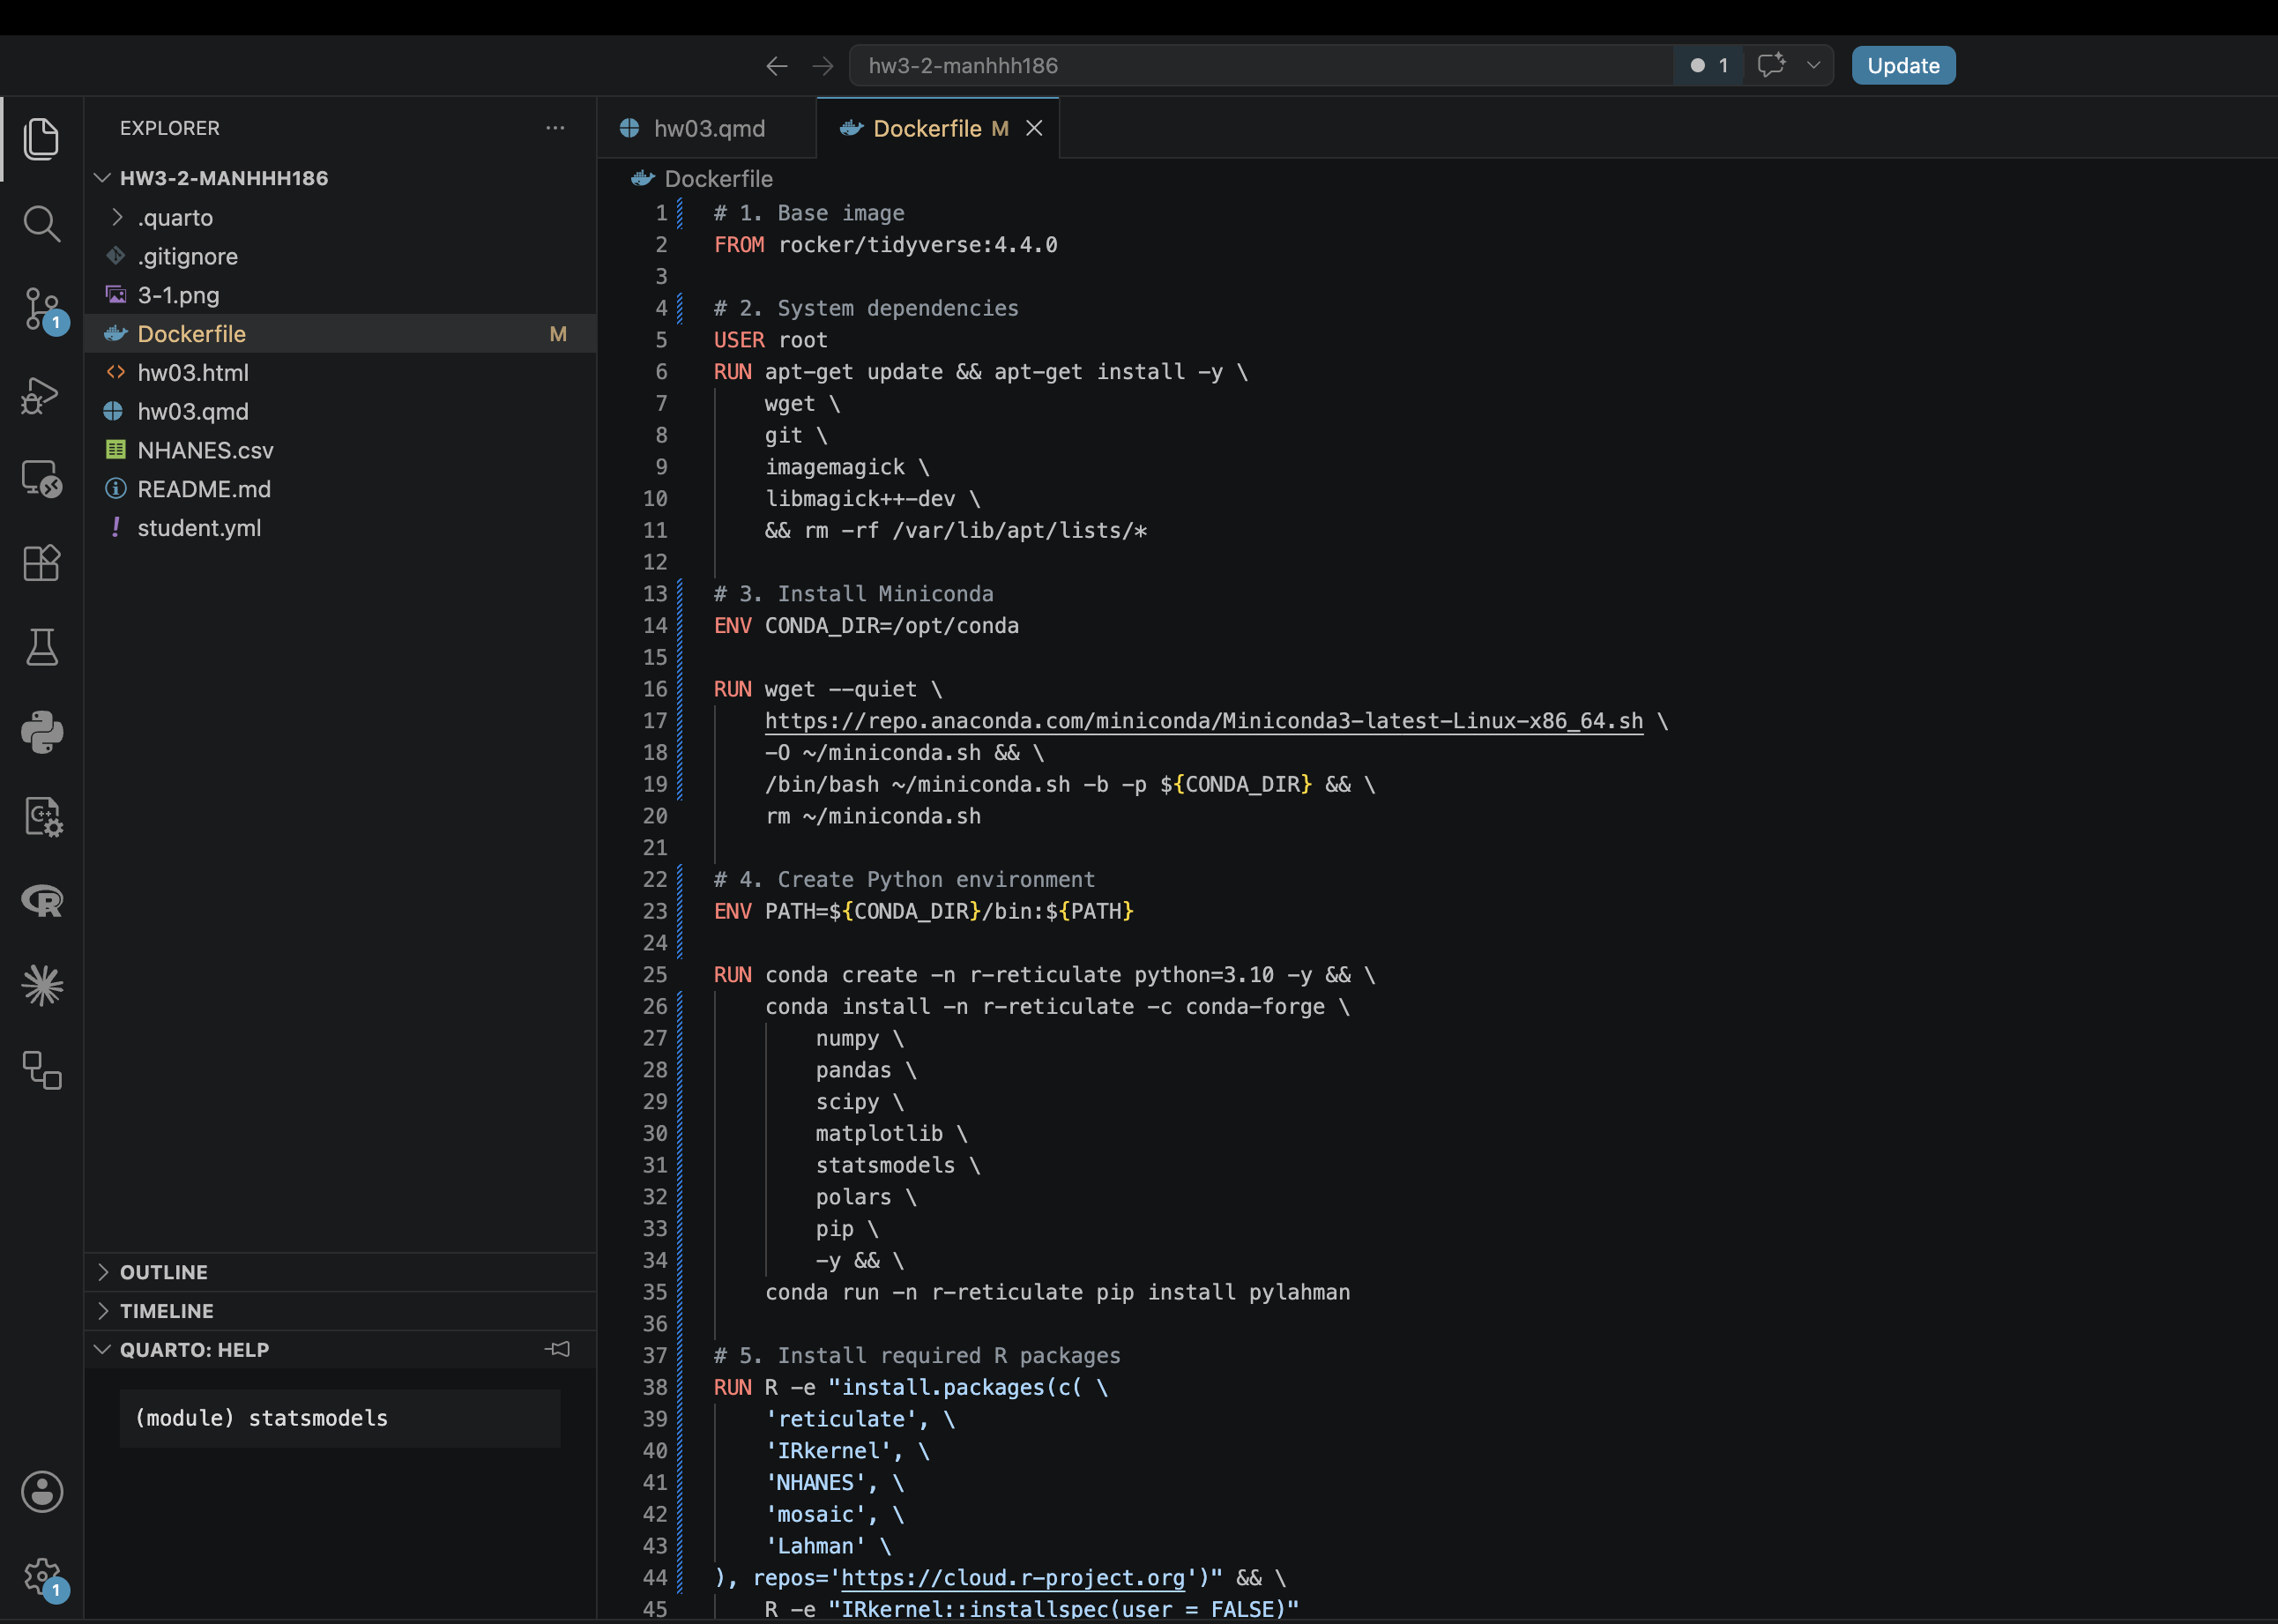

## 문제 3-2. GitHub Actions 워크플로우 수정

숙제 2에서 만들었던 `publish.yml`을 수정하여 기존의 배포 단계 끝에
Docker 컨테이너 이미지를 빌드하고 Github Container Registry (GHCR)에
푸시하는 단계를 추가한다.

In [ ]:
# ... (기존 Quarto Render 단계 이후)

      - name: Log in to GitHub Container Registry
        uses: docker/login-action@v3
        with:
          registry: ghcr.io
          username: ${{ github.actor }}
          password: ${{ secrets.GITHUB_TOKEN }}

      - name: Build and push Docker image
        uses: docker/build-push-action@v5
        with:
          context: .
          push: true
          tags: ghcr.io/${{ github.repository_owner }}/my-r-env:latest

### 답안

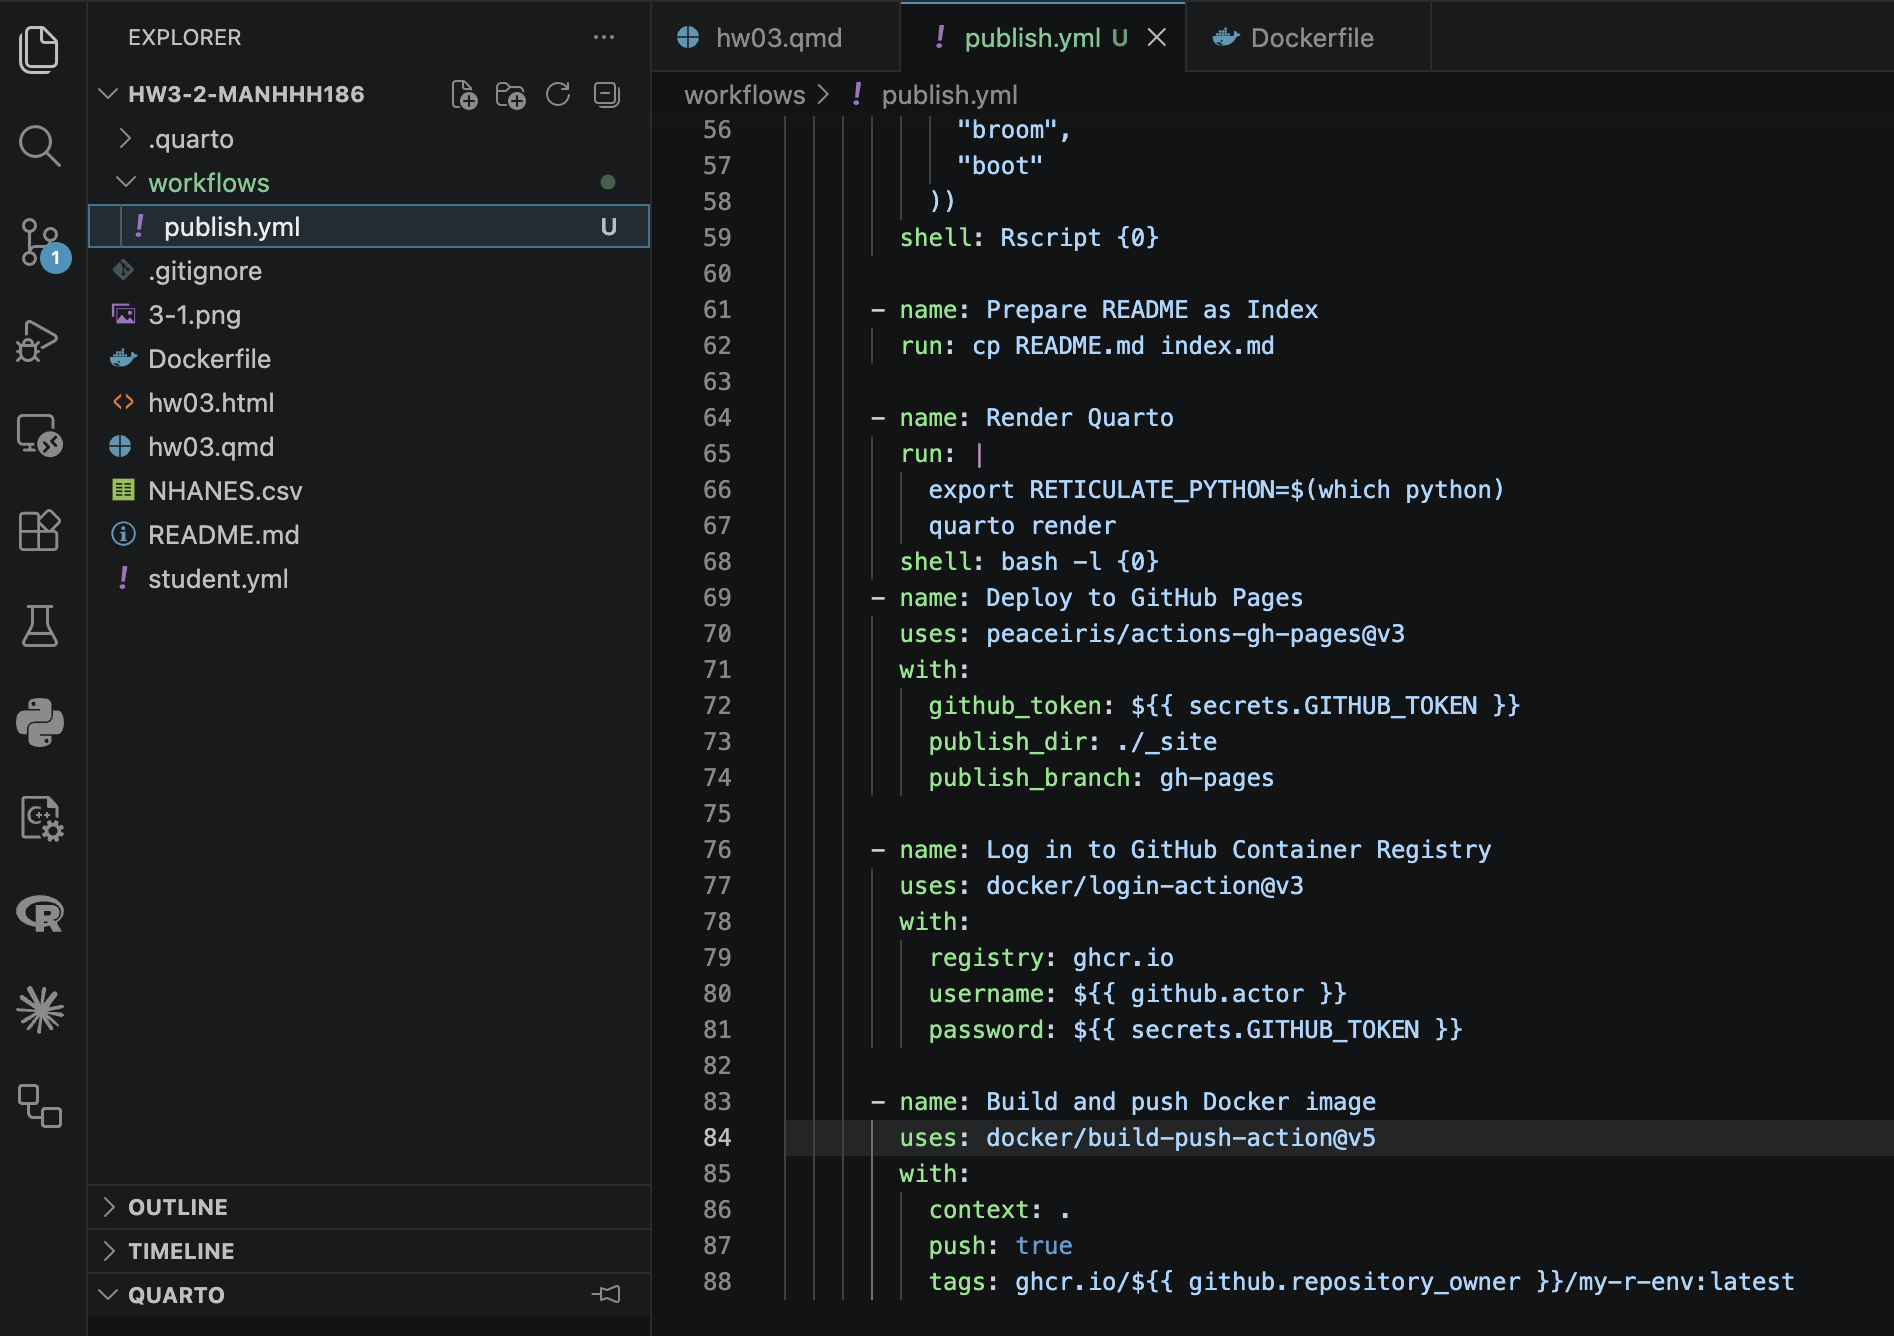

## 문제 3-3. GitHub Pages에 Binder 링크 추가

GitHub Page를 사용하여 저장소를 웹페이지로 활용하는 부분은 숙제 2에서와
같다.

웹페이지에서 노트북을 내려받는 대신 [Binder](mybinder.org) 서비스를
이용하여 온라인으로 노트북을 실행할 수 있도록 위해 `README.md` 파일을
로컬 저장소 최상위 디렉토리에 다음과 같이 만들자.

In [ ]:
# 숙제 3

이름: [아무개]
학번: [나의 학번]

이 숙제의 상세 분석 결과는 아래 링크에서 확인하실 수 있습니다.

* [분석 리포트 (HTML)](./hw03.html) 
* [주피터 노트북 (ipynb)](https://mybinder.org/v2/gh/<유저명>/snu-stat/<repo명>/gh-pages?filepath=hw03.ipynb

여기서 `<유저명>`은 제출자의 GitHub 유저 아이디이며, `<repo명>`은 hw3-로
시작하는 제출자의 repository 이름이다.

작업을 GitHub 원격 저장소로 push한 후 숙제 2 문제 3-3의 3, 4번 과정을
반복하라.

### 답안